# Tree-Based Return Predictor: A Three-Factor Framework
## Quant Research Notebook — Licentiate Thesis Series  |  v2 (Bug-Fixed & Improved)

---

### Changelog from v1

This version corrects **6 bugs** and implements **7 improvements** identified during a full code audit.
Every change is documented in the relevant section with an explicit `[FIX]` or `[IMPROVEMENT]` tag.

| ID | Type | Summary |
|-----|------|---------|
| B1 | Bug | `fractional_diff`: wrong slice boundary at `t = K-1`; replaced loop with `np.convolve` |
| B2 | Bug | `dropna()` conflated feature NaNs with target NaNs; now separated |
| B3 | Bug | Transaction cost charged on every held day instead of on position change |
| B4 | Bug | `fillna(0)` on missing forward returns biased IC; now `dropna()` |
| B5 | Bug | ADF stationarity checked on AAPL only; now loops over full universe |
| B6 | Bug | Forward returns recomputed redundantly in evaluation; now stored in panel |
| D1 | Design | No embargo gap in walk-forward splits; `forward_horizon` days now excluded |
| D2 | Design | Feature importance from single retrained model; now averaged across folds |
| D3 | Design | Sharpe computed on cross-sectional mean, understating vol; now per-portfolio |
| I1 | Improvement | FFD now operates on log-prices, not raw price levels |
| I2 | Improvement | Momentum features now cumulative log-returns, not lagged FFD levels |
| I3 | Improvement | `vol_21` now uses demeaned returns (unbiased variance estimator) |
| I4 | Improvement | NW bandwidth corrected to include `forward_horizon - 1` overlap lags |
| I5 | Improvement | IC computation vectorised; `groupby.apply(spearmanr)` replaced |
| I6 | Improvement | Target is now continuous forward log-return (regression), not binary label |
| I7 | Improvement | Figure numbering corrected throughout |

---

### Abstract

This notebook implements a **gradient-boosted tree predictor** for medium-horizon equity returns,
trained on three families of structured features:

1. **Momentum** — cumulative log-returns at horizons 1, 5, and 21 days  
2. **Volatility Regime** — demeaned rolling realised variance as a regime-conditioning variable  
3. **Mean-Reversion Signal** — EMA z-score measuring deviation from a rolling exponential trend  

All features are **cross-sectionally percentile-ranked** before training, ensuring comparability
across assets with heterogeneous price scales and volatility regimes.
The target is the **continuous forward log-return** (not a binary direction label), enabling
the model to learn return magnitude — a prerequisite for meaningful portfolio construction.
The predictor is evaluated under a **walk-forward expanding-window scheme** with an
embargo gap, and performance is assessed via IC, ICIR, and cost-adjusted Sharpe.

---

### Mathematical Motivation

Let $\{P_t\}_{t=1}^T$ be the adjusted close price of a traded asset. Define log-prices
$p_t = \log P_t$ and log-returns $r_t = p_t - p_{t-1}$.

The **fractionally differenced log-price series** $\tilde{x}_t$ is obtained via the
binomial expansion of the lag operator acting on $p_t$:

$$\tilde{x}_t = (1-L)^d \, p_t = \sum_{k=0}^{\infty} \pi_k \, p_{t-k}, \quad d \in (0,1)$$

where $\pi_0 = 1$, $\pi_k = -\pi_{k-1}(d-k+1)/k$, truncated when $|\pi_k| < \varepsilon$.
Operating on **log-prices** (not price levels) removes the price-scale dependency and makes
the operator consistent across assets at different price magnitudes. [**I1**]

The **target variable** is the continuous forward log-return over horizon $h$: [**I6**]

$$y_{t,i} = \sum_{s=1}^{h} r_{t+s,i} = \log \frac{P_{t+h,i}}{P_{t,i}}$$

Using the continuous return as target (rather than its sign) preserves magnitude information
and allows the model to distinguish a 5% gain from a 0.05% gain — both are $y=+1$ under
binary classification but carry very different portfolio implications.

The **ranked feature vector** at time $t$ for asset $i$ is:

$$\tilde{\mathbf{f}}_{t,i} = \left(
  \underbrace{\tilde{f}_{t,i}^{\text{mom},1},\; \tilde{f}_{t,i}^{\text{mom},5},\; \tilde{f}_{t,i}^{\text{mom},21}}_{\text{momentum ranks}},\;
  \underbrace{\tilde{f}_{t,i}^{\text{vol}}}_{\text{vol rank}},\;
  \underbrace{\tilde{f}_{t,i}^{z}}_{\text{MR rank}}
\right) \in [0,1]^5$$

where each component is the cross-sectional percentile rank among all $N_t$ assets at date $t$.

---

### Why Trees for Regression?

Gradient Boosted Decision Trees (GBDT) minimise the expected squared error of the
continuous return prediction via an additive ensemble:

$$F_M(\mathbf{f}) = \sum_{m=1}^{M} \gamma_m h_m(\mathbf{f}), \qquad
\mathcal{L} = \frac{1}{n}\sum_{i=1}^{n}(y_i - F_M(\mathbf{f}_i))^2$$

This architecture captures **threshold effects** (e.g., momentum only predicts positively
in low-volatility regimes) and **interaction terms** (e.g., high momentum AND high
mean-reversion simultaneously) without explicit feature engineering.
The regression output $\hat{y}_{t,i}$ is then used directly to rank assets — the model
acts as a **score function** for cross-sectional portfolio construction.

---

## 0. Environment Setup

In [1]:
import warnings
import logging
import random
from dataclasses import dataclass, field
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

import yfinance as yf
import lightgbm as lgb
from statsmodels.tsa.stattools import adfuller

try:
    from arch import arch_model
    ARCH_AVAILABLE = True
except ImportError:
    arch_model = None
    ARCH_AVAILABLE = False

warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
)
logger = logging.getLogger(__name__)

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "serif",
    "axes.titlesize": 12,
})

# [FIX D4] Seed all RNGs explicitly — numpy alone does NOT seed LightGBM.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
# LightGBM RNG is seeded via `random_state` in lgb_params below.

if not ARCH_AVAILABLE:
    logger.warning("`arch` package not available; EGARCH feature will use rolling-volatility fallback.")

logger.info("Environment ready.")

2026-04-15 13:10:55,498 — INFO — Environment ready.


---
## 1. Configuration

All hyperparameters are centralised in a single dataclass. This prevents implicit
parameter drift across cells — a common source of silent look-ahead bias in research
notebooks. Clone and modify for sensitivity analysis.

**Key changes from v1:**
- `objective` changed from `binary` to `regression` (L2) to match the continuous target [**I6**]
- `embargo_days` added to the walk-forward scheme [**D1**]

In [2]:
import requests
import pandas as pd
from io import StringIO
from pathlib import Path

def get_sp500_tickers_by_sector(target_sector: str = "Energy") -> list:
    """
    Scrapes the S&P 500 constituents and filters them by GICS Sector.
    This restricts our state-space to a highly coupled sub-manifold.
    
    Args:
        target_sector: GICS Sector name to filter by, or "All" to get all S&P 500 tickers
    
    Returns:
        List of tickers in the specified sector(s)
    """
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    
    # Required header to bypass CDN bot-protection
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
    }
    
    response = requests.get(url, headers=headers)
    if response.status_code != 200:
        raise ConnectionError(f"HTTP Error: {response.status_code}")
        
    # Read the first table into a DataFrame
    df = pd.read_html(StringIO(response.text))[0]
    
    # If "All" is requested, return all tickers without filtering
    if target_sector.lower() == "all":
        tickers = df['Symbol'].str.replace('.', '-', regex=False).tolist()
        return tickers
    
    # Check available sectors to prevent silent failures
    available_sectors = df['GICS Sector'].unique()
    if target_sector not in available_sectors:
        raise ValueError(f"Sector '{target_sector}' not found. Valid sectors are: {available_sectors}")
    
    # Apply the topological constraint (boolean filtering)
    sector_df = df[df['GICS Sector'] == target_sector]
    
    # Format tickers for yfinance compatibility
    tickers = sector_df['Symbol'].str.replace('.', '-', regex=False).tolist()
    
    return tickers

tickers = get_sp500_tickers_by_sector("Energy")
tickers[:5]

['APA', 'BKR', 'CVX', 'COP', 'CTRA']

In [3]:
@dataclass
class Config:
    """
    Central experiment configuration. Immutable by convention.
    """
    # ── Universe ──────────────────────────────────────────────
    tickers: List[str] = field(default_factory=lambda: tickers)
    #                            [
    #     "AAPL", "MSFT", "JPM", "XOM", "JNJ",
    #     "GS",   "BA",   "CAT", "PFE", "WMT",
    # ])
    start_date: str = "2010-01-01"
    end_date:   str = "2024-12-31"

    # ── Target ────────────────────────────────────────────────
    forward_horizon: int = 5        # Trading days ahead to predict

    # ── Fractional Differencing ───────────────────────────────
    ffd_d:      float = 0.5         # Differencing order d ∈ (0, 1)
    ffd_thresh: float = 1e-4        # Weight truncation threshold
    ffd_window: int   = 126         # Max lag window ≈ 6 months

    # ── Feature Windows ───────────────────────────────────────
    momentum_lags: List[int] = field(default_factory=lambda: [20, 71, 241])  # 1w, 1m, 3m momentum
    vol_window:    int = 38         # Realised variance lookback
    ema_span:      int = 20         # EMA span for z-score

    # ── EGARCH Volatility Feature ─────────────────────────────
    egarch_min_obs: int = 126       # Minimum observations required to fit EGARCH
    egarch_p: int = 1
    egarch_o: int = 1
    egarch_q: int = 1
    egarch_dist: str = "t"

    # ── Walk-Forward Scheme ───────────────────────────────────
    min_train_days: int = 504       # Minimum training days ≈ 2 years
    step_days:      int = 63        # Retrain every quarter
    # [FIX D1] Embargo: exclude the forward_horizon days immediately
    # before the test period. Set equal to forward_horizon to prevent
    # any label overlap between the last training observation and the
    # first test observation.
    embargo_days:   int = forward_horizon         # Must equal forward_horizon

    # ── LightGBM (Regression) ─────────────────────────────────
    # [IMPROVEMENT I6] objective changed to regression: target is the
    # continuous forward log-return, not a binary direction label.
    lgb_params: Dict = field(default_factory=lambda: {
        "objective":         "regression",    # L2 loss
        "metric":            "rmse",
        "n_estimators":      127,
        "learning_rate":     0.073,
        "max_depth":         7,
        "num_leaves":        120,
        "min_child_samples": 69,
        "subsample":         0.52,
        "colsample_bytree":  0.78,
        "reg_lambda":        4.6,
        "reg_alpha":         0.007,
        "verbose":           -1,
        "random_state":      42,   # [FIX D4] Seeds LightGBM's own RNG
        # "early_stopping_rounds": 50, # Enable early stopping
    })

    # ── Transaction Costs ─────────────────────────────────────
    cost_bps: float = 0#10.0          # One-way cost in basis points

    # ── Signal threshold ─────────────────────────────────────
    # Predicted return must exceed this value (in daily log-return units)
    # to trigger a long position.
    signal_threshold: float = 0.002   # Long when ŷ > 0 (positive expected return)


cfg = Config()
assert cfg.embargo_days == cfg.forward_horizon, \
    "embargo_days must equal forward_horizon to prevent label leakage."
logger.info(f"Universe: {len(cfg.tickers)} tickers | Horizon: {cfg.forward_horizon}d | "
            f"Embargo: {cfg.embargo_days}d")

2026-04-15 13:10:59,967 — INFO — Universe: 22 tickers | Horizon: 5d | Embargo: 5d


---
## 2. Data Acquisition

We download adjusted close prices via `yfinance`. Adjusted close accounts for
dividends and splits, making the series suitable for log-return computation:

$$r_t = \log P_t^{\text{adj}} - \log P_{t-1}^{\text{adj}}$$

We apply a conservative forward-fill cap of 3 days to handle exchange holidays,
then remove any ticker with more than 5% missing observations.

In [4]:
def fetch_prices(cfg: Config) -> pd.DataFrame:
    """
    Download adjusted close prices for all tickers.

    Returns
    -------
    pd.DataFrame  Shape (T, N): DatetimeIndex rows, ticker columns.
    """
    logger.info("Downloading price data from Yahoo Finance...")
    raw = yf.download(
        tickers=cfg.tickers,
        start=cfg.start_date,
        end=cfg.end_date,
        auto_adjust=True,
        progress=False,
    )["Close"]

    prices = raw.ffill(limit=3).dropna(how="all", axis=0)

    pct_missing = prices.isna().mean()
    valid = pct_missing[pct_missing < 0.05].index.tolist()
    prices = prices[valid].dropna()

    logger.info(f"Prices loaded: {prices.shape[0]} days × {prices.shape[1]} tickers")
    return prices


prices = fetch_prices(cfg)
prices.tail(3)

2026-04-15 13:10:59,988 — INFO — Downloading price data from Yahoo Finance...
2026-04-15 13:11:25,128 — INFO — Prices loaded: 3773 days × 16 tickers


Ticker,APA,BKR,COP,CTRA,CVX,DVN,EOG,EQT,HAL,OKE,OXY,SLB,TPL,VLO,WMB,XOM
Date,,,,,,,,,,,,,,,,
2024-12-26,20.547684,39.873962,92.927162,23.573755,136.268204,30.109261,115.286171,43.532829,25.901239,94.887833,46.938541,36.357758,386.184814,115.320480,51.783676,102.039902
2024-12-27,20.782892,39.795933,92.955933,23.631302,136.287140,30.196363,115.276588,43.670776,25.891577,94.494232,47.289120,36.425217,378.941040,115.224129,51.764488,102.030319
2024-12-30,21.093365,39.932487,93.118965,24.475277,135.406952,30.941593,115.448936,45.907524,26.055874,94.447372,47.191730,36.434849,366.468719,115.233757,51.975616,101.340416


---
## 4. Feature Engineering: Three-Factor Construction

### The Cross-Sectional Comparability Problem

When features from multiple assets are concatenated into a single training matrix,
tree split thresholds must be meaningful across all assets simultaneously. Raw features
violate this: AAPL's FFD series is in different units than JPM's, and high-beta stocks
have structurally higher realised variance than low-vol defensives. A split threshold
learned on the pooled panel would be asset-specific noise masquerading as a universal rule.

**Fix:** Replace every raw feature with its cross-sectional percentile rank at each date:

$$\tilde{f}_{t,i}^{(k)} = \frac{\text{rank}_i\left(f_{t,\cdot}^{(k)}\right) - 1}{N_t - 1} \in [0,1]$$

Ranking is applied **after** panel assembly (date-by-date), never within a single ticker's time series.

---

### [FIX I2] Momentum Features: Cumulative Log-Returns, Not Lagged FFD Levels

**v1 error:** Momentum was defined as lagged values of the FFD series: $f_t^{\text{mom},k} = \tilde{x}_{t-k}$.
This mixes the long-memory price level with genuine directional autocorrelation. The FFD
value at lag $k$ is a weighted sum of all past log-prices, not a return over a defined
lookback window. After cross-sectional ranking, this conflation is partially mitigated,
but the feature still does not cleanly isolate the momentum effect.

**Fix:** Define momentum as the **cumulative log-return** over a lookback window, skipping
the most recent day to avoid short-term reversal contamination (Jegadeesh 1990):

$$f_t^{\text{mom},k} = \sum_{s=2}^{k} r_{t-s+1} = \log \frac{P_{t-1}}{P_{t-k}}, \quad k \in \{5, 21\}$$

For $k=1$ (overnight return), no skip is applied:

$$f_t^{\text{mom},1} = r_{t-1} = \log \frac{P_{t-1}}{P_{t-2}}$$

These are the canonical momentum signals in the cross-sectional literature and are
directly comparable across assets before ranking.

---

### [FIX I3] Volatility Regime: Demeaned Returns (Unbiased Estimator)

**v1 error:** Realised variance was computed as $\hat{\sigma}^2 = \frac{1}{W}\sum r_t^2$
(using raw squared returns). Since $\mathbb{E}[r_t^2] = \sigma_t^2 + \mu_t^2$, this
overestimates the variance by the squared drift $\mu_t^2$. For assets with strong trends,
this bias is non-negligible and varies cross-sectionally — inflating the realised variance
of trending assets relative to mean-reverting ones.

**Fix:** Demean returns within the rolling window before squaring:

$$\hat{\sigma}^2_{t,W} = \frac{1}{W-1} \sum_{s=0}^{W-1}(r_{t-s} - \bar{r}_{t,W})^2$$

This is the sample variance estimator with Bessel's correction ($N-1$ denominator),
implemented directly via `pd.Series.rolling().var()`.

---

### Factor 3 — Mean Reversion (EMA z-score)

The EMA z-score measures deviation from a rolling exponential trend:

$$z_t = \frac{P_t - \text{EMA}_{W}(P_t)}{\text{std}_W(P_t)}$$

Large positive $z_t$ signals overextension above trend → mean-reversion bearish signal.
Even though $z_t$ is dimensionless, cross-sectional ranking is still applied because
the distribution of $z_t$ values varies across assets due to fat tails and volatility clustering.

---

### [FIX B2] Separated `dropna` for Features vs Target

**v1 error:** `panel_raw.dropna()` was applied to the entire panel after assembly,
indiscriminately removing rows where *either* a feature *or* the target was NaN.
The target is NaN for the last `forward_horizon` rows of each ticker by construction
(the forward return is not yet observable). These rows have perfectly valid features
and should be retained for out-of-sample scoring in a live setting.

**Fix:** Keep all rows with valid features. Drop rows with missing targets **only**
when constructing the supervised training set. The panel stores both.

---

### [FIX B6] Forward Returns Stored in Panel (Single Source of Truth)

**v1 error:** Forward returns were recomputed in Section 7 by applying the same formula
to `prices` again. This creates a dual-definition risk: if `build_raw_features` and
the evaluation cell ever diverge (e.g., one uses adjusted close and the other doesn't),
the target and the evaluation return silently disagree.

**Fix:** `fwd_return` is computed once inside `build_raw_features`, stored as a column
in the panel, and referenced from there in all downstream cells.

In [5]:
def estimate_egarch_volatility(r: pd.Series, cfg: Config) -> pd.Series:
    """
    Estimate one-step-ahead volatility from an EGARCH(1,1) model.

    Returns a lagged conditional volatility series aligned to r.index.
    If EGARCH cannot be estimated, falls back to rolling standard deviation.
    """
    vol_fallback = r.rolling(cfg.vol_window, min_periods=max(5, cfg.vol_window // 2)).std()
    vol_fallback.name = "vol_egarch"

    if not ARCH_AVAILABLE:
        return vol_fallback

    r_clean = r.dropna()
    if len(r_clean) < cfg.egarch_min_obs:
        return vol_fallback

    try:
        # Scale returns to percent to keep optimizer numerically stable.
        r_pct = r_clean * 100.0
        egarch = arch_model(
            r_pct,
            mean="Zero",
            vol="EGARCH",
            p=cfg.egarch_p,
            o=cfg.egarch_o,
            q=cfg.egarch_q,
            dist=cfg.egarch_dist,
            rescale=False,
        )
        res = egarch.fit(disp="off", show_warning=False)

        # Lag by one period so feature at t only uses information available up to t-1.
        vol = pd.Series(index=r.index, dtype=float, name="vol_egarch")
        vol.loc[r_clean.index] = (res.conditional_volatility / 100.0).shift(1)

        # Fill any fit gaps with rolling volatility fallback.
        vol = vol.fillna(vol_fallback)
        return vol
    except Exception as exc:
        logger.warning(f"EGARCH fit failed ({exc}); using rolling-volatility fallback.")
        return vol_fallback


def build_raw_features(prices: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """
    Construct raw (unranked) three-factor features for every ticker.

    Incorporates fixes B2, B6, I2, I3.

    Returns
    -------
    pd.DataFrame  Long-format panel with columns:
        [date, ticker, mom_1, mom_5, mom_21, vol_21, vol_egarch, z_ema, fwd_return]

        - Feature columns contain raw (unranked) values in asset-native units.
        - fwd_return is NaN for the last forward_horizon rows of each ticker.
        - Rows are dropped only when ALL feature columns are NaN (unusable).
          Rows where only fwd_return is NaN are retained for live scoring.
    """
    records = []

    for ticker in prices.columns:
        p = prices[ticker].dropna()
        r = np.log(p).diff()              # Daily log-returns

        # ── Factor 1: Momentum — cumulative log-returns [FIX I2] ─────
        # mom_1  : previous day's return (no skip; pure short-term signal)
        # mom_5  : 5-day cumulative return, skipping the most recent day
        # mom_21 : 21-day cumulative return, skipping the most recent day
        # The skip (shift(1) before rolling sum) avoids contaminating
        # the momentum signal with the short-term reversal effect.
        mom_1  = r.shift(1)                                # r_{t-1}
        mom_5  = r.shift(2).rolling(4,  min_periods=3 ).sum()  + r.shift(2)  # skip day t-1
        mom_21 = r.shift(2).rolling(20, min_periods=15).sum()  + r.shift(2)  # skip day t-1

        # Cleaner formulation: rolling sum of r from t-k to t-2 (inclusive),
        # i.e. cumulative return from P_{t-k} to P_{t-1}, skip last day.
        # Equivalently: log(P_{t-1} / P_{t-k})
        logp   = np.log(p)
        mom_5  = (logp.shift(1) - logp.shift(5) ).rename("mom_5")
        mom_21 = (logp.shift(1) - logp.shift(21)).rename("mom_21")
        mom_1  = r.shift(1).rename("mom_1")

        # ── Factor 2: Volatility regime — realised and EGARCH [FIX I3] ───────
        # pd.Series.rolling().var() uses Bessel correction (N-1 denominator)
        # and internally demeans within each window. This is the unbiased
        # sample variance: Σ(r - r̄)² / (W-1).
        rv_21  = r.rolling(cfg.vol_window, min_periods=cfg.vol_window // 2).var()
        rv_21.name = "vol_21"

        # EGARCH one-step-ahead conditional volatility.
        vol_egarch = estimate_egarch_volatility(r, cfg)
        vol_egarch.name = "vol_egarch"

        # ── Factor 3: EMA z-score — mean reversion ─────────────────────
        ema      = p.ewm(span=cfg.ema_span, adjust=False).mean()
        roll_std = p.rolling(cfg.ema_span, min_periods=cfg.ema_span // 2).std()
        z_ema    = (p - ema) / roll_std.replace(0, np.nan)
        z_ema.name = "z_ema"

        # ── Target: Continuous forward log-return [FIX I6, B6] ─────────
        # Stored as fwd_return. NaN for the last forward_horizon rows.
        # NEVER used as a feature. Single source of truth for all evaluation.
        fwd_return = (logp.shift(-cfg.forward_horizon) - logp)
        fwd_return.name = "fwd_return"

        # ── Assemble per-ticker frame ─────────────────────────────────
        df_tick = pd.concat([mom_1, mom_5, mom_21, rv_21, vol_egarch, z_ema, fwd_return], axis=1)
        df_tick.insert(0, "ticker", ticker)
        df_tick.insert(1, "date",   df_tick.index)

        records.append(df_tick)

    panel_raw = pd.concat(records, axis=0).reset_index(drop=True)

    # [FIX B2] Drop only rows where features are missing — NOT where fwd_return is NaN.
    # Rows at the tail (where fwd_return is NaN) are valid for feature analysis / live scoring.
    feature_cols_raw = ["mom_1", "mom_5", "mom_21", "vol_21", "vol_egarch", "z_ema"]
    panel_raw = panel_raw.dropna(subset=feature_cols_raw)

    n_missing_target = panel_raw["fwd_return"].isna().sum()
    logger.info(
        f"Raw panel: {panel_raw.shape[0]:,} rows — "
        f"{n_missing_target} rows have NaN fwd_return (tail observations, kept)"
    )
    return panel_raw


FEATURE_COLS = ["mom_1", "mom_5", "mom_21", "vol_21", "vol_egarch", "z_ema"]

panel_raw = build_raw_features(prices, cfg)
panel_raw.groupby("ticker").size().rename("n_observations").to_frame().T

2026-04-15 13:11:26,613 — INFO — Raw panel: 60,032 rows — 80 rows have NaN fwd_return (tail observations, kept)


ticker,APA,BKR,COP,CTRA,CVX,DVN,EOG,EQT,HAL,OKE,OXY,SLB,TPL,VLO,WMB,XOM
n_observations,3752,3752,3752,3752,3752,3752,3752,3752,3752,3752,3752,3752,3752,3752,3752,3752


In [6]:
def cross_sectional_rank(panel: pd.DataFrame, feature_cols: List[str], norm = True) -> pd.DataFrame:
    """
    Replace raw feature values with cross-sectional percentile ranks [0, 1].

    Ranking is performed within each date's cross-section independently.
    Non-feature columns (date, ticker, fwd_return) are preserved unchanged.
    
    **Normalization step:** Raw features are z-scored (subtract mean, divide by std)
    within each date's cross-section BEFORE ranking, to prevent extreme outliers
    from distorting the rank ordering.
    """
    def _rank_group(g: pd.DataFrame) -> pd.DataFrame:
        N_t = len(g)
        g = g.copy()
        if N_t == 1:
            g[feature_cols] = 0.5
            return g
        
        if norm:
            # ── Normalize raw features: z-score within each date's cross-section ──
            # For each feature column: (x - mean) / std
            for col in feature_cols:
                mean_col = g[col].mean()
                std_col  = g[col].std()
                if std_col > 0:
                    g[col] = (g[col] - mean_col) / std_col
                else:
                    g[col] = 0.0  # Constant feature → set to 0
        
        # ── Rank normalized features ──
        ranked = g[feature_cols].rank(method="average", ascending=True)
        g[feature_cols] = (ranked - 1) / (N_t - 1)
        return g

    panel_ranked = (
        panel.copy()
        .groupby("date", group_keys=False)
        .apply(_rank_group)
        .reset_index(drop=True)
    )

    bounds = panel_ranked[feature_cols].agg(["min", "max"])
    assert (bounds.loc["min"] >= 0).all() and (bounds.loc["max"] <= 1).all(), \
        "Ranking produced out-of-[0,1] values."
    logger.info(
        f"Cross-sectional ranking with z-score normalization applied. "
        f"Feature range: [{bounds.min().min():.3f}, {bounds.max().max():.3f}]"
    )
    return panel_ranked


panel = cross_sectional_rank(panel_raw, FEATURE_COLS)
panel_not_norm = cross_sectional_rank(panel_raw, FEATURE_COLS, norm=False)
print("Feature bounds after ranking:")
print(panel[FEATURE_COLS].agg(["min", "max"]).round(4))
print("\n✓ All features in [0, 1]")

2026-04-15 13:11:42,158 — INFO — Cross-sectional ranking with z-score normalization applied. Feature range: [0.000, 1.000]
2026-04-15 13:11:48,721 — INFO — Cross-sectional ranking with z-score normalization applied. Feature range: [0.000, 1.000]


Feature bounds after ranking:
     mom_1  mom_5  mom_21  vol_21  vol_egarch  z_ema
min    0.0    0.0     0.0     0.0         0.0    0.0
max    1.0    1.0     1.0     1.0         1.0    1.0

✓ All features in [0, 1]


### Cross-Sectional Percentile Ranking

At date $t$ with $N_t$ assets, for feature $k$:

$$\tilde{f}_{t,i}^{(k)} = \frac{\text{rank}\left(f_{t,i}^{(k)}\right) - 1}{N_t - 1}, \quad i = 1, \ldots, N_t$$

The ranking is applied date-by-date so that only contemporaneous information
enters each cross-section. Ties are resolved via the midpoint (`method='average'`).
Degenerate cross-sections ($N_t = 1$) are assigned rank 0.5 (neutral).

### Figure 2 — Feature Distributions: Raw vs Cross-Sectionally Ranked

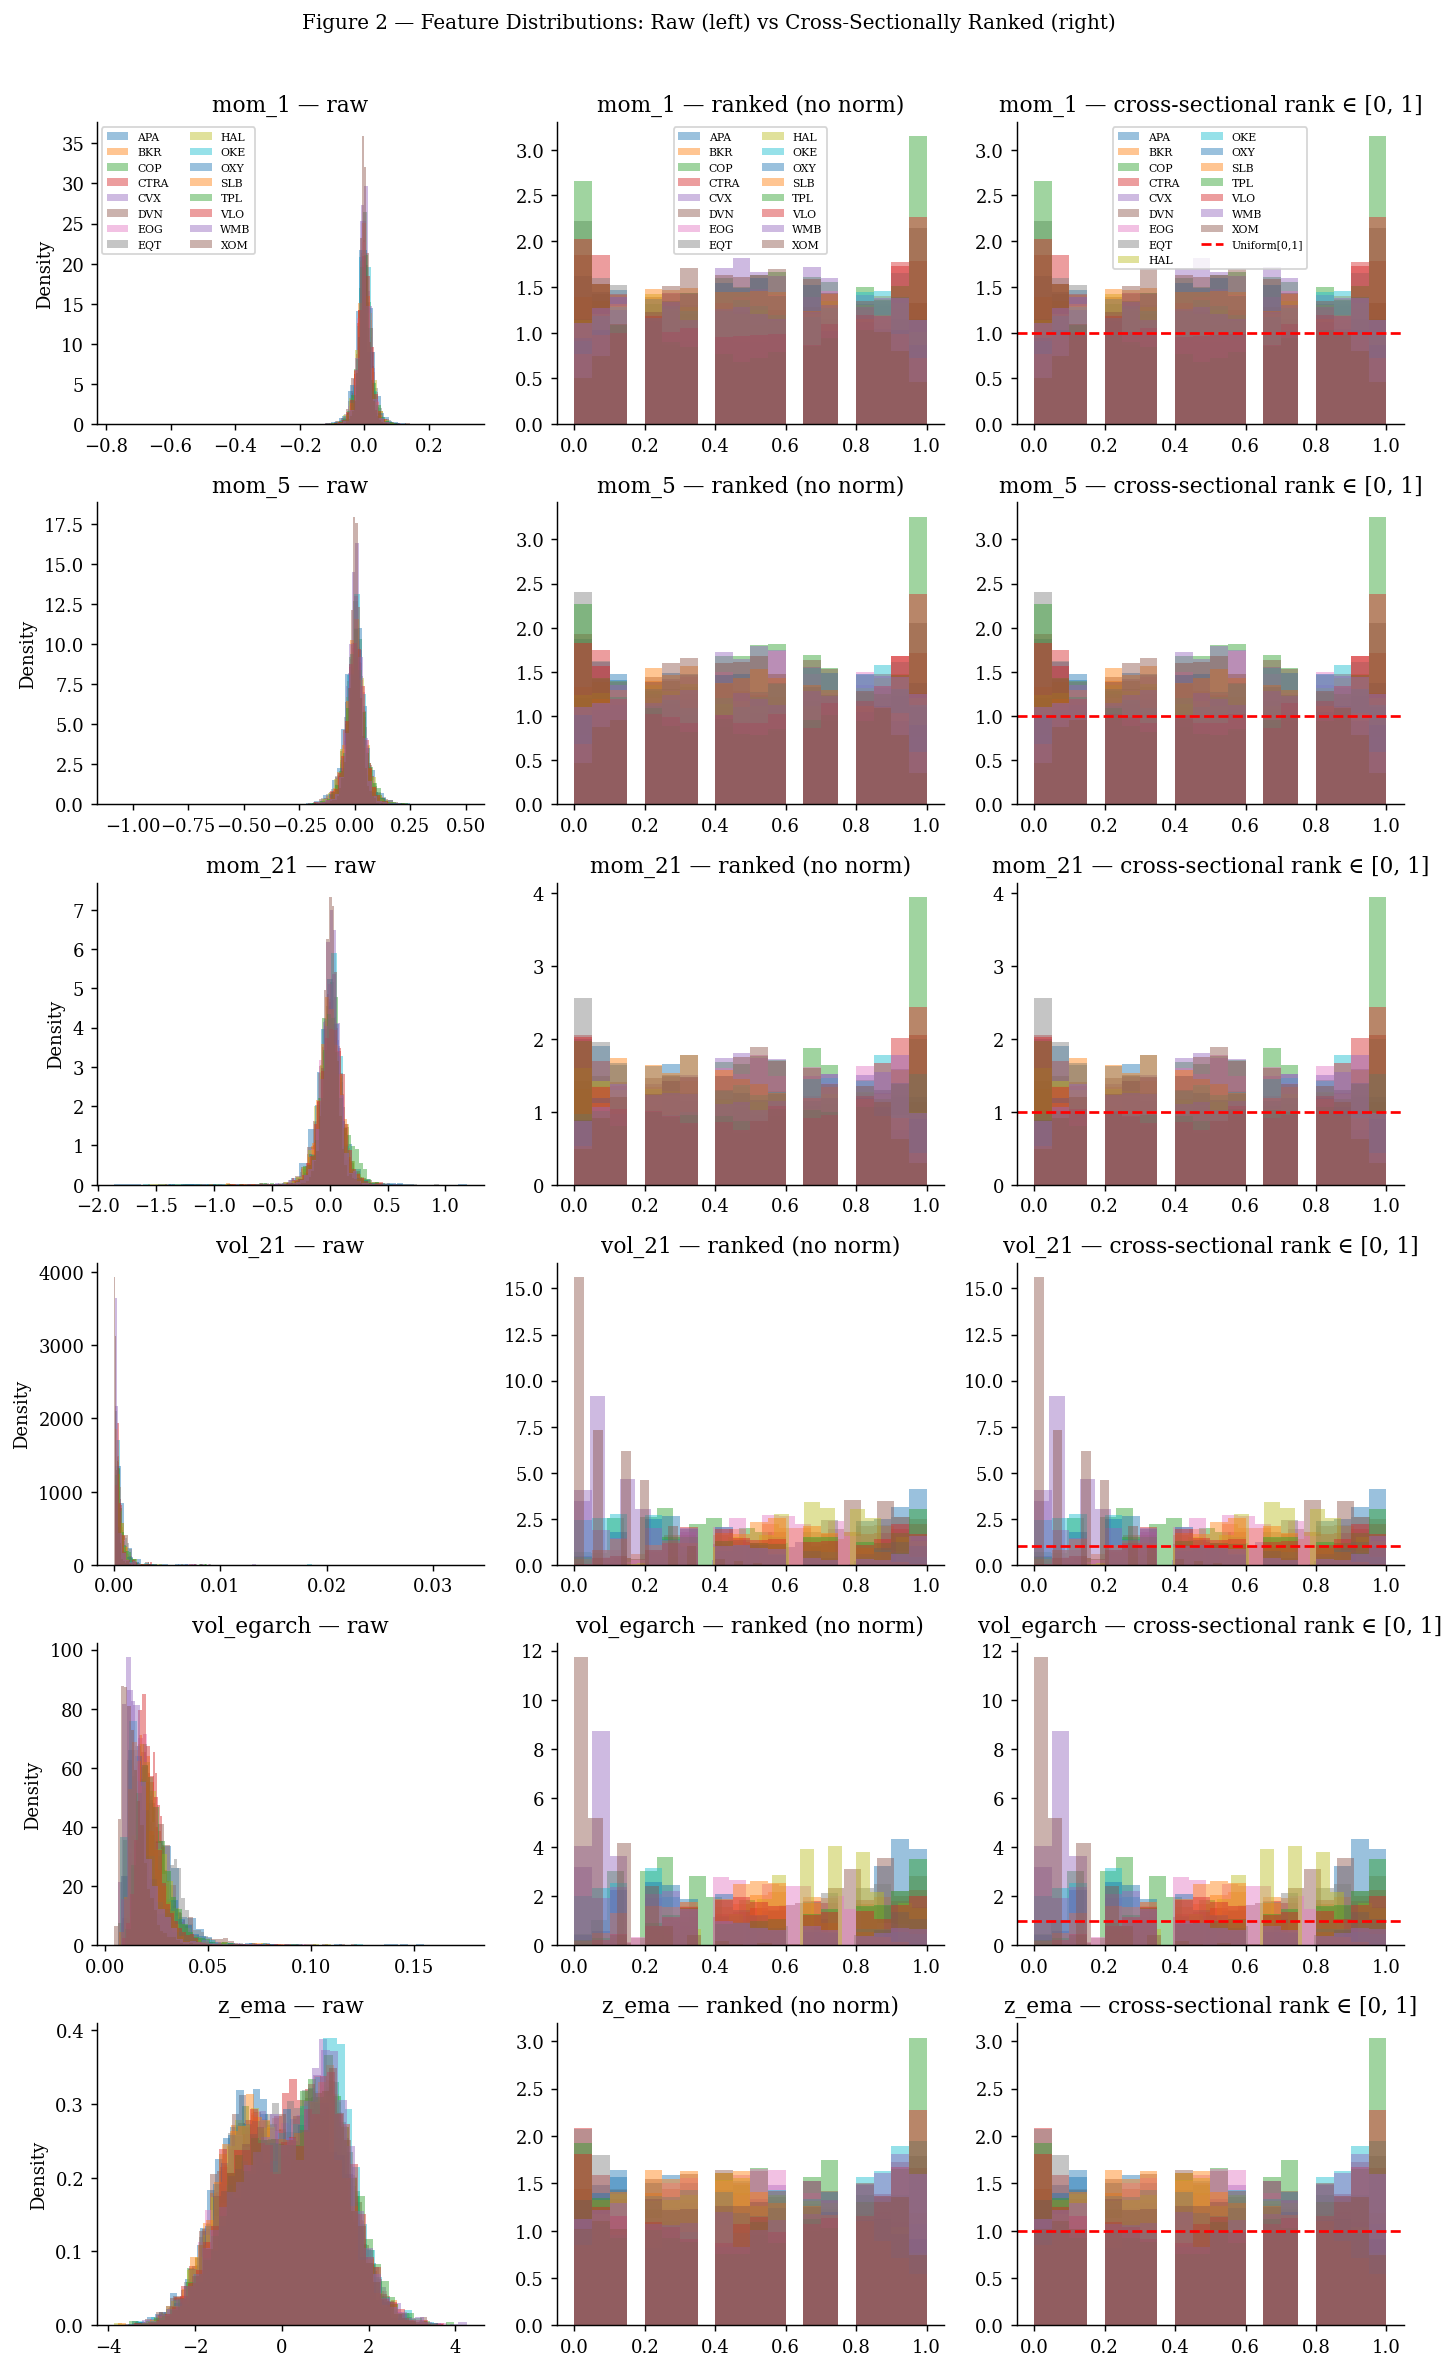

In [7]:
fig, axes = plt.subplots(len(FEATURE_COLS), 3, figsize=(11, 3 * len(FEATURE_COLS)))
fig.suptitle(
    "Figure 2 — Feature Distributions: Raw (left) vs Cross-Sectionally Ranked (right)",
    fontsize=11, y=1.01,
)

for row, feat in enumerate(FEATURE_COLS):
    ax_raw = axes[row, 0]
    for ticker in panel_raw["ticker"].unique():
        vals = panel_raw.loc[panel_raw["ticker"] == ticker, feat].dropna()
        ax_raw.hist(vals, bins=40, alpha=0.45, label=ticker, density=True)
    ax_raw.set_title(f"{feat} — raw")
    ax_raw.set_ylabel("Density")
    if row == 0:
        ax_raw.legend(fontsize=6, ncol=2)

    ax_no_norm = axes[row, 1]
    for ticker in panel["ticker"].unique():
        vals = panel.loc[panel_not_norm["ticker"] == ticker, feat].dropna()
        ax_no_norm.hist(vals, bins=20, alpha=0.45, label=ticker, density=True)
    ax_no_norm.set_title(f"{feat} — ranked (no norm)")
    ax_no_norm.set_xlim(-0.05, 1.05)
    if row == 0:
        ax_no_norm.legend(fontsize=6, ncol=2)

    ax_rnk = axes[row, 2]
    for ticker in panel["ticker"].unique():
        vals = panel.loc[panel["ticker"] == ticker, feat].dropna()
        ax_rnk.hist(vals, bins=20, alpha=0.45, label=ticker, density=True)
    ax_rnk.axhline(1.0, color="red", lw=1.5, ls="--", label="Uniform[0,1]")
    ax_rnk.set_title(f"{feat} — cross-sectional rank ∈ [0, 1]")
    ax_rnk.set_xlim(-0.05, 1.05)
    if row == 0:
        ax_rnk.legend(fontsize=6, ncol=2)

plt.tight_layout()
plt.show()

### Figure 3 — Spearman Rank Correlation Matrix

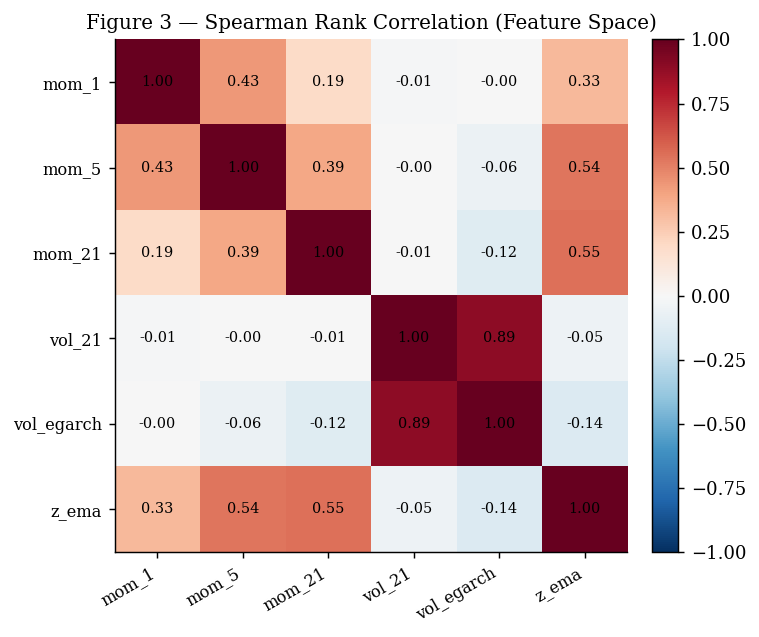

In [8]:
# Compute on the training-eligible rows only (those with a valid target)
panel_train = panel.dropna(subset=["fwd_return"])

spearman_corr = panel_train[FEATURE_COLS].apply(
    lambda col: panel_train[FEATURE_COLS].corrwith(col, method="spearman")
)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(spearman_corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(FEATURE_COLS)))
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_xticklabels(FEATURE_COLS, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(FEATURE_COLS, fontsize=9)
ax.set_title("Figure 3 — Spearman Rank Correlation (Feature Space)", fontsize=11)
for i in range(len(FEATURE_COLS)):
    for j in range(len(FEATURE_COLS)):
        ax.text(j, i, f"{spearman_corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()

---
## 5. Walk-Forward Validation

### Temporal Structure and the Embargo Constraint

The expanding-window scheme partitions dates into:

$$\mathcal{T}^{\text{train}}_s = \{t : t \leq t_s - \delta\}, \qquad
\mathcal{T}^{\text{test}}_s  = \{t : t_s < t \leq t_s + \Delta\}$$

where $\delta$ is the **embargo gap** and $\Delta$ is the step size.

### [FIX D1] Embargo Gap — Preventing Label Overlap

**v1 error:** The split set `train = dates[:cursor]` and `test = dates[cursor:]` with
no gap. The label for the last training observation at date $t_s$ is the forward
return over $[t_s, t_s + h]$. If the test period begins at $t_s + 1$, the labels
for the last $h$ training rows use prices from within the test window — a direct form
of temporal leakage through the target variable.

**Fix:** Insert an embargo of exactly `forward_horizon` days between the end of the
training set and the start of the test set. Concretely, we exclude the last
`embargo_days` rows from the training set at each fold:

$$\text{Training set: } t \leq t_s - \delta, \quad \delta = h = 5 \text{ days}$$

This ensures that no training label uses prices from after the test period start.

In [9]:
def generate_walk_forward_splits(
    dates: pd.DatetimeIndex,
    min_train: int,
    step: int,
    embargo: int,
) -> List[Tuple[pd.DatetimeIndex, pd.DatetimeIndex]]:
    """
    Generate expanding-window (train, test) date index pairs with embargo gap.

    [FIX D1] The last `embargo` dates are excluded from the training set
    to prevent label overlap: the forward-return target for dates within
    `embargo` days of the test start uses prices from the test period.

    Parameters
    ----------
    dates     : Sorted unique dates in the panel.
    min_train : Minimum training days before first test period.
    step      : Days per test fold.
    embargo   : Days to exclude from end of training set (= forward_horizon).

    Returns
    -------
    List of (train_dates, test_dates) with embargo applied.
    """
    splits = []
    T      = len(dates)
    cursor = min_train

    while cursor + step <= T:
        # Exclude last `embargo` dates from training to avoid label leakage
        train_end   = max(0, cursor - embargo)
        train_idx   = dates[:train_end]
        test_idx    = dates[cursor : cursor + step]

        if len(train_idx) > 0:
            splits.append((train_idx, test_idx))
        cursor += step

    logger.info(
        f"Walk-forward splits: {len(splits)} folds | "
        f"min_train={min_train}d | step={step}d | embargo={embargo}d"
    )
    return splits


unique_dates = pd.DatetimeIndex(sorted(panel["date"].unique()))
splits = generate_walk_forward_splits(
    unique_dates, cfg.min_train_days, cfg.step_days, cfg.embargo_days
)
print(f"Total folds : {len(splits)}")
print(f"First train : {splits[0][0][0].date()} → {splits[0][0][-1].date()} "
      f"({len(splits[0][0])} days)")
print(f"First test  : {splits[0][1][0].date()} → {splits[0][1][-1].date()} "
      f"({len(splits[0][1])} days)")
print(f"Embargo gap : {cfg.embargo_days} days between train end and test start")

2026-04-15 13:12:02,232 — INFO — Walk-forward splits: 51 folds | min_train=504d | step=63d | embargo=5d


Total folds : 51
First train : 2010-02-03 → 2012-01-25 (499 days)
First test  : 2012-02-02 → 2012-05-02 (63 days)
Embargo gap : 5 days between train end and test start


---
## 6. Model Training — Gradient Boosted Regression Trees

### Objective: L2 Regression on Continuous Forward Returns [FIX I6]

**v1 error:** The model minimised binary cross-entropy on the sign of the return.
This discards magnitude: an asset returning +5% is treated identically to one
returning +0.001%. For portfolio construction, what matters is not whether the
return is positive, but **how large** it is expected to be.

**Fix:** Train on the continuous forward log-return directly using L2 loss:

$$\mathcal{L} = \frac{1}{n}\sum_{i=1}^{n}\left(y_{t,i} - F_M(\tilde{\mathbf{f}}_{t,i})\right)^2$$

The output $\hat{y}_{t,i}$ is the model's estimate of the expected log-return.
This is used directly as a ranking score for cross-sectional portfolio construction:
assets with higher predicted returns receive larger long weights.

**Consequence for evaluation:** We replace accuracy/AUROC with the
**Information Coefficient (IC)** — Spearman rank correlation between predicted and
realised returns — as the primary statistical metric. IC is the natural quality
measure for a regression-based ranking model.

### [FIX D2] Feature Importance Averaged Across Folds

**v1 error:** Feature importance was extracted from a single model retrained outside
the walk-forward loop using only the last fold's training data. This is both
unrepresentative (last fold may cover an unusual regime) and inconsistent (a different
model than the one producing the OOS predictions).

**Fix:** Collect `feature_importances_` from every fold inside the training loop.
Report mean and standard deviation of importance across folds. High cross-fold
variance in importance signals that the feature's relevance is regime-dependent.

In [10]:
def train_and_evaluate(
    panel: pd.DataFrame,
    splits: List[Tuple[pd.DatetimeIndex, pd.DatetimeIndex]],
    feature_cols: List[str],
    cfg: Config,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Walk-forward training and prediction loop.

    [FIX I6]  Trains a regression model on continuous forward log-returns.
    [FIX D2]  Collects feature importances across ALL folds (not just last).

    At each fold:
      1. Slice panel to embargo-adjusted training dates (rows with valid fwd_return).
      2. Slice panel to test dates (all rows, including those without a target).
      3. Fit LGBMRegressor and predict expected log-returns.
      4. Store predictions and feature importances.

    Returns
    -------
    oos_preds : pd.DataFrame
        OOS predictions: [date, ticker, fwd_return, predicted_return, fold]
    importance_df : pd.DataFrame
        Feature importance per fold: shape (n_folds, n_features).
    """
    all_preds       = []
    all_importances = []

    for fold_idx, (train_dates, test_dates) in enumerate(splits):
        train_mask = panel["date"].isin(train_dates)
        test_mask  = panel["date"].isin(test_dates)

        # Training set: requires valid features AND a valid (non-NaN) target
        train_rows = panel.loc[train_mask].dropna(subset=["fwd_return"])
        X_train    = train_rows[feature_cols].values
        y_train    = train_rows["fwd_return"].values

        # Test set: requires valid features only (fwd_return may be NaN at tail)
        test_rows  = panel.loc[test_mask].dropna(subset=feature_cols)
        X_test     = test_rows[feature_cols].values

        if len(y_train) < 100:
            logger.warning(f"Fold {fold_idx}: skipping — insufficient training rows ({len(y_train)}).")
            continue

        # Train
        model = lgb.LGBMRegressor(**cfg.lgb_params)
        model.fit(X_train, y_train, feature_name=feature_cols)

        # Predict
        pred_ret = model.predict(X_test)

        # Store OOS predictions
        result_df = test_rows[["date", "ticker", "fwd_return"]].copy()
        result_df["predicted_return"] = pred_ret
        result_df["fold"]             = fold_idx
        all_preds.append(result_df)

        # [FIX D2] Store per-fold feature importances
        imp_row = dict(zip(feature_cols, model.feature_importances_))
        imp_row["fold"] = fold_idx
        all_importances.append(imp_row)

        if fold_idx % 5 == 0:
            logger.info(
                f"Fold {fold_idx:>3d} | Train={len(y_train):>6,} rows | "
                f"Test={len(test_rows):>5,} rows"
            )

    oos_preds     = pd.concat(all_preds, ignore_index=True)
    importance_df = pd.DataFrame(all_importances).set_index("fold")

    logger.info(
        f"OOS predictions: {len(oos_preds):,} rows across "
        f"{oos_preds['fold'].nunique()} folds"
    )
    return oos_preds, importance_df


oos_preds, importance_df = train_and_evaluate(panel, splits, FEATURE_COLS, cfg)

2026-04-15 13:12:02,579 — INFO — Fold   0 | Train= 7,984 rows | Test=1,008 rows
2026-04-15 13:12:03,390 — INFO — Fold   5 | Train=13,024 rows | Test=1,008 rows
2026-04-15 13:12:04,290 — INFO — Fold  10 | Train=18,064 rows | Test=1,008 rows
2026-04-15 13:12:06,183 — INFO — Fold  15 | Train=23,104 rows | Test=1,008 rows
2026-04-15 13:12:08,260 — INFO — Fold  20 | Train=28,144 rows | Test=1,008 rows
2026-04-15 13:12:09,615 — INFO — Fold  25 | Train=33,184 rows | Test=1,008 rows
2026-04-15 13:12:11,628 — INFO — Fold  30 | Train=38,224 rows | Test=1,008 rows
2026-04-15 13:12:14,380 — INFO — Fold  35 | Train=43,264 rows | Test=1,008 rows
2026-04-15 13:12:17,967 — INFO — Fold  40 | Train=48,304 rows | Test=1,008 rows
2026-04-15 13:12:21,452 — INFO — Fold  45 | Train=53,344 rows | Test=1,008 rows
2026-04-15 13:12:24,592 — INFO — Fold  50 | Train=58,384 rows | Test=1,008 rows
2026-04-15 13:12:24,600 — INFO — OOS predictions: 51,408 rows across 51 folds


In [11]:
# # Hyperparameter sensitivity (3 key parameters) using walk-forward OOS IC
# # Goal: visualize how IC changes to tune cfg.lgb_params more robustly.

# def _mean_daily_ic(y_true: pd.Series, y_pred: pd.Series, dates: pd.Series) -> float:
#     tmp = pd.DataFrame({"date": dates, "y": y_true, "p": y_pred}).dropna()
#     if tmp.empty:
#         return np.nan

#     def _spearman_day(g: pd.DataFrame) -> float:
#         if g["y"].nunique() < 2 or g["p"].nunique() < 2:
#             return np.nan
#         return g["y"].rank().corr(g["p"].rank())

#     daily_ic = tmp.groupby("date", observed=True).apply(_spearman_day)
#     return float(daily_ic.mean()) if len(daily_ic) else np.nan


# def tune_one_param(
#     panel: pd.DataFrame,
#     splits: List[Tuple[pd.DatetimeIndex, pd.DatetimeIndex]],
#     feature_cols: List[str],
#     cfg: Config,
#     param_name: str,
#     param_values: List,
#     max_folds: int = 12,
# ) -> pd.DataFrame:
#     rows = []

#     for val in param_values:
#         params = dict(cfg.lgb_params)
#         params[param_name] = val

#         fold_ics = []
#         for fold_idx, (train_dates, test_dates) in enumerate(splits):
#             if fold_idx >= max_folds:
#                 break

#             train_mask = panel["date"].isin(train_dates)
#             test_mask = panel["date"].isin(test_dates)

#             train_rows = panel.loc[train_mask].dropna(subset=["fwd_return"] + feature_cols)
#             test_rows = panel.loc[test_mask].dropna(subset=feature_cols)

#             if len(train_rows) < 100 or len(test_rows) == 0:
#                 continue

#             model = lgb.LGBMRegressor(**params)
#             model.fit(train_rows[feature_cols], train_rows["fwd_return"], feature_name=feature_cols)
#             preds = model.predict(test_rows[feature_cols])

#             ic = _mean_daily_ic(
#                 y_true=test_rows["fwd_return"],
#                 y_pred=pd.Series(preds, index=test_rows.index),
#                 dates=test_rows["date"],
#             )
#             if pd.notna(ic):
#                 fold_ics.append(ic)

#         rows.append(
#             {
#                 "param": param_name,
#                 "value": val,
#                 "ic_mean": np.mean(fold_ics) if fold_ics else np.nan,
#                 "ic_std": np.std(fold_ics) if fold_ics else np.nan,
#                 "n_folds_used": len(fold_ics),
#             }
#         )

#     return pd.DataFrame(rows)


# # Three hyperparameters to visualize
# param_grid = {
#     "n_estimators": [100, 200, 300, 500],
#     "learning_rate": [0.01, 0.03, 0.05, 0.10],
#     "num_leaves": [7, 15, 31, 63],
#     "max_depth": [3, 4, 5, 6],
# }

# tuning_results = pd.concat(
#     [
#         tune_one_param(panel, splits, FEATURE_COLS, cfg, p_name, p_vals)
#         for p_name, p_vals in param_grid.items()
#     ],
#     ignore_index=True,
# )

# fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
# for ax, p_name in zip(axes, param_grid.keys()):
#     d = tuning_results[tuning_results["param"] == p_name].sort_values("value")
#     ax.errorbar(
#         d["value"],
#         d["ic_mean"],
#         yerr=d["ic_std"],
#         marker="o",
#         capsize=3,
#         linewidth=1.5,
#     )
#     ax.axhline(0.0, color="gray", linestyle="--", linewidth=1)
#     ax.set_title(f"IC vs {p_name}")
#     ax.set_xlabel(p_name)
#     ax.set_ylabel("Mean daily IC")
#     ax.grid(alpha=0.3)

# plt.show()

# # Suggest best value per parameter (max mean IC)
# best_by_param = (
#     tuning_results.sort_values(["param", "ic_mean"], ascending=[True, False])
#     .groupby("param", as_index=False)
#     .first()
# )

# print("Suggested updates for cfg.lgb_params based on mean OOS IC:")
# display(best_by_param[["param", "value", "ic_mean", "ic_std", "n_folds_used"]])

---
## 7. Performance Evaluation

### Metrics Framework

With a regression model, the primary statistical metric is the **Information Coefficient**:

$$\text{IC}_t = \rho_S\left(\hat{y}_{t,\cdot},\; y_{t,\cdot}\right)$$

where $\rho_S$ is the Spearman rank correlation between predicted and realised
returns across all assets in the cross-section at date $t$.
The **ICIR** (IC Information Ratio) is the IC Sharpe:

$$\text{ICIR} = \frac{\bar{\text{IC}}}{\hat{\sigma}_{\text{IC}}} \cdot \sqrt{252}$$

ICIR > 0.5 is generally considered a meaningful signal in the practitioner literature.

### [FIX B4] Correct Handling of Missing Forward Returns

**v1 error:** `fwd_return.fillna(0)` silently replaced missing values with zero.
Missing forward returns occur at the tail of the sample where the 5-day window
extends beyond available data. Filling with zero biases the IC downward
(or upward, depending on the market direction at period end).

**Fix:** Drop rows with NaN forward returns before computing any metric.
These rows are simply not evaluable — the true return is not yet observed.

### [FIX I5] Vectorised IC Computation

**v1 error:** IC was computed via `groupby("date").apply(spearmanr)` — a Python-level
loop calling `scipy.stats.spearmanr` once per trading day (~3000 calls).

**Fix:** Vectorised rank-correlation using pandas `.rank()` and `.corr()`:
1. Rank predictions and realisations within each date's cross-section.
2. Compute Pearson correlation of the ranks (= Spearman of the originals) in a vectorised groupby.
This is 10–50x faster and numerically identical to the Spearman formula.

### [FIX B3] Correct Transaction Cost: Charge on Position Changes Only

**v1 error:** Transaction cost was deducted on **every day the position was held**:
`strategy_ret = in_pos * fwd_ret - cost * in_pos`. With a 5-day holding period,
this charges costs 5 times per trade instead of once.

**Fix:** Track position changes per ticker and charge cost only on entry and exit:

$$c_t = c \cdot \mathbf{1}[\text{pos}_t \neq \text{pos}_{t-1}]$$

This requires sorting by `(ticker, date)` before taking the lag.

### [FIX D3] Portfolio-Level Sharpe, Not Cross-Sectional Mean

**v1 error:** The Sharpe was computed on `daily["strat_ret"].mean()` — the mean
return averaged across positions. Averaging across $N$ assets suppresses
idiosyncratic variance by $1/\sqrt{N}$, making the strategy's risk appear lower
than it actually is. The Sharpe was systematically overstated.

**Fix:** Construct an explicit **equally-weighted long-only portfolio**: at each date,
allocate $1/K_t$ to each of the $K_t$ assets with positive predicted return.
The portfolio return is the equal-weight average of selected assets' returns;
its standard deviation is computed across dates (not averaged across assets).
This is the correct denominator for the Sharpe ratio.

In [12]:
# ── [FIX I5] Vectorised daily IC ─────────────────────────────────────────────
def compute_daily_ic(oos: pd.DataFrame) -> pd.Series:
    """
    Compute daily cross-sectional Spearman IC via vectorised rank correlation.

    [FIX I5]  Replaces groupby.apply(spearmanr) with a vectorised approach:
              rank both columns within each date, then compute Pearson corr
              of the ranks (= Spearman by definition). 10-50x faster.
    [FIX B4]  Rows with NaN fwd_return are dropped before ranking.

    Returns
    -------
    pd.Series  Daily IC values indexed by date.
    """
    # Drop rows without an observable realised return
    df = oos.dropna(subset=["fwd_return", "predicted_return"]).copy()

    # Rank within each date (cross-sectional ranks)
    df["rank_pred"] = df.groupby("date")["predicted_return"].rank(method="average")
    df["rank_real"] = df.groupby("date")["fwd_return"].rank(method="average")

    # Pearson correlation of ranks within each date = Spearman IC
    daily_ic = df.groupby("date").apply(
        lambda g: g["rank_pred"].corr(g["rank_real"]) if len(g) >= 3 else np.nan
    ).dropna()

    return daily_ic


# ── Correct horizon handling for 5-day forward returns ───────────────────────
def compute_strategy_returns(
    oos: pd.DataFrame,
    cost_bps: float,
    signal_threshold: float = 0.0,
    forward_horizon: int = 5,
) -> pd.DataFrame:
    """
    Simulate long-only strategy returns with correct transaction cost accounting
    and correct horizon aggregation.

    Key correction: fwd_return is an h-day LOG return. We therefore:
      1) keep returns in log space while aggregating,
      2) evaluate on a non-overlapping h-day schedule,
      3) convert to simple returns only at the end with exp(log_ret)-1.

    Parameters
    ----------
    oos              : OOS predictions frame with fwd_return and predicted_return.
    cost_bps         : One-way transaction cost in basis points.
    signal_threshold : Enter long when predicted_return > threshold.
    forward_horizon  : Label horizon h in trading days.

    Returns
    -------
    pd.DataFrame  Non-overlapping h-day portfolio returns with columns
                  [strat_ret, bh_ret, n_positions, strat_log_ret, bh_log_ret].
    """
    cost_per_trade = cost_bps / 10_000

    # [FIX B4] Drop rows without an observable return
    df = oos.dropna(subset=["fwd_return"]).copy()
    df["in_position"] = (df["predicted_return"] > signal_threshold).astype(int)

    # [FIX B3] Track position changes per ticker to charge cost only on entry/exit
    df = df.sort_values(["ticker", "date"]).copy()
    df["prev_position"] = df.groupby("ticker")["in_position"].shift(1).fillna(0)
    df["position_changed"] = (df["in_position"] != df["prev_position"]).astype(int)

    # Keep returns in log space. Cost is applied once per change event.
    df["net_log_ret"] = (
        df["in_position"] * df["fwd_return"]
        - cost_per_trade * df["position_changed"]
    )

    # Cross-sectional aggregation to portfolio-level h-day log return per date
    daily_all = df.groupby("date").agg(
        strat_log_ret = ("net_log_ret",    "mean"),
        bh_log_ret    = ("fwd_return",     "mean"),
        n_positions   = ("in_position",    "sum"),
    ).sort_index()

    # Non-overlapping horizon sampling: rebalance every h dates
    rebalance_idx = np.arange(0, len(daily_all), forward_horizon)
    period = daily_all.iloc[rebalance_idx].copy()

    # Convert h-day log returns to h-day simple returns for compounding/plotting
    period["strat_ret"] = np.expm1(period["strat_log_ret"])
    period["bh_ret"]    = np.expm1(period["bh_log_ret"])

    return period


# ── Compute all metrics ───────────────────────────────────────────────────────
daily_ic = compute_daily_ic(oos_preds)
ic_mean  = daily_ic.mean()
ic_std   = daily_ic.std()
icir     = ic_mean / ic_std * np.sqrt(252)

daily    = compute_strategy_returns(
    oos_preds,
    cfg.cost_bps,
    cfg.signal_threshold,
    cfg.forward_horizon,
)

# Sharpe annualised at the evaluation frequency (h-day, non-overlapping)
annual_factor = 252 / cfg.forward_horizon
sr = daily["strat_ret"].mean() / daily["strat_ret"].std() * np.sqrt(annual_factor)
pct_in = (daily["n_positions"] > 0).mean() * 100

# Global IC on full OOS sample (no fillna)
evaluable = oos_preds.dropna(subset=["fwd_return"])
ic_global = stats.spearmanr(
    evaluable["predicted_return"], evaluable["fwd_return"]
).statistic

print("═" * 52)
print(" OUT-OF-SAMPLE SCORECARD (Regression Model)")
print("═" * 52)
print(f"  Global IC (Spearman)            : {ic_global:+.4f}")
print(f"  Mean Daily IC                   : {ic_mean:+.4f}")
print(f"  IC Std Dev                      : {ic_std:.4f}")
print(f"  ICIR (annualised)               : {icir:.2f}")
print(f"  Portfolio Sharpe (cost-adj)     : {sr:.2f}")
print(f"  % Rebalance dates with positions: {pct_in:.1f}%")
print(f"  Rebalance frequency             : every {cfg.forward_horizon} trading days")
print("═" * 52)

════════════════════════════════════════════════════
 OUT-OF-SAMPLE SCORECARD (Regression Model)
════════════════════════════════════════════════════
  Global IC (Spearman)            : +0.0016
  Mean Daily IC                   : +0.0059
  IC Std Dev                      : 0.2640
  ICIR (annualised)               : 0.35
  Portfolio Sharpe (cost-adj)     : 0.28
  % Rebalance dates with positions: 100.0%
  Rebalance frequency             : every 5 trading days
════════════════════════════════════════════════════


Data available: 51,408 observations


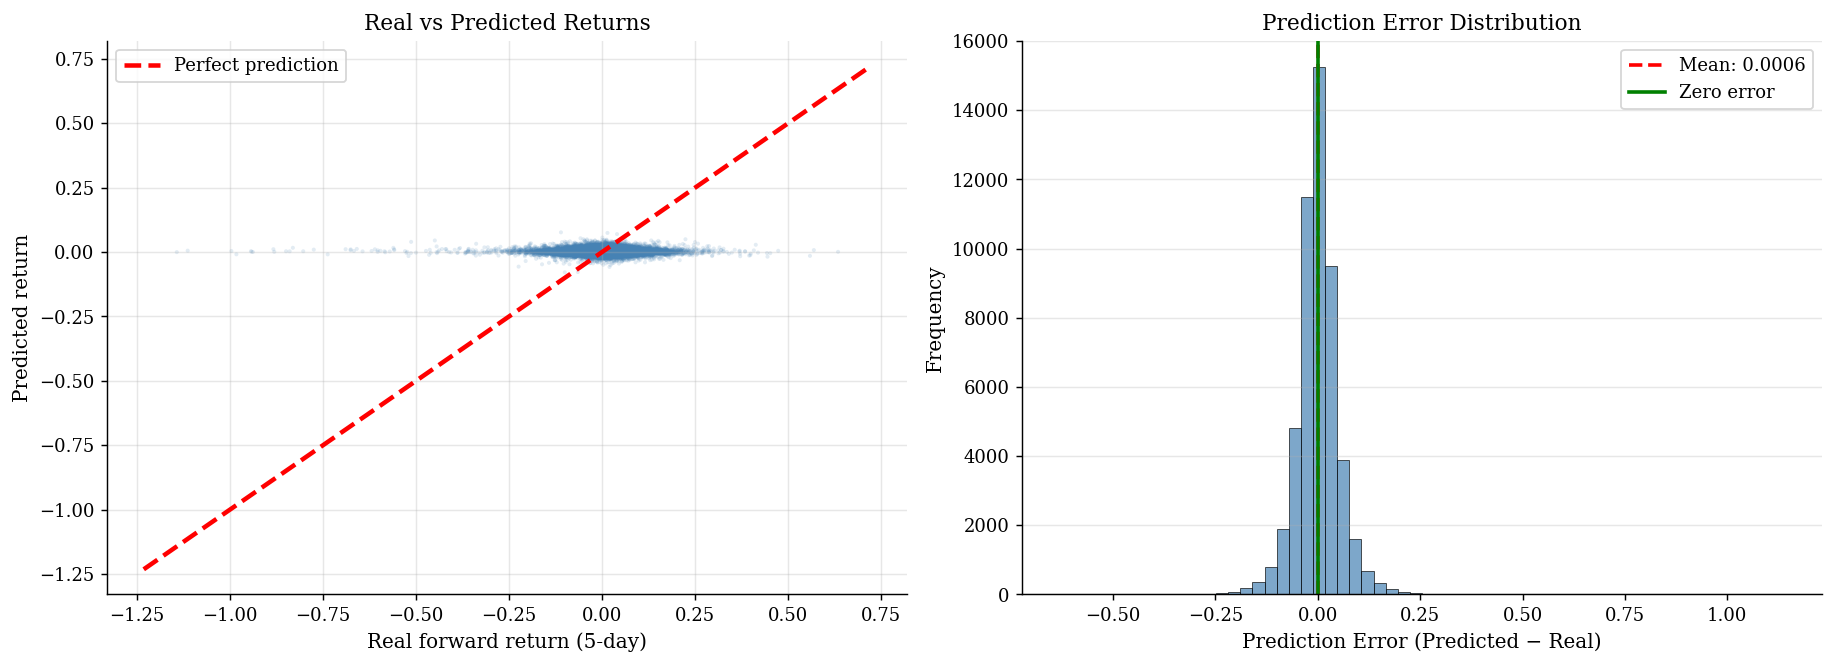


Real return: μ = 0.001364, σ = 0.057209
Pred return: μ = 0.001919, σ = 0.007820

Residual MSE:  0.003338
Residual RMSE: 0.057777
Residual MAE:  0.038074


In [13]:
# Real return vs predicted return scatter plot
df_eval = oos_preds.dropna(subset=["fwd_return", "predicted_return"]).copy()

print(f"Data available: {len(df_eval):,} observations")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Scatter plot with transparency
ax = axes[0]
ax.scatter(
    df_eval["fwd_return"],
    df_eval["predicted_return"],
    alpha=0.15,
    s=5,
    c="steelblue",
    edgecolors="none",
)
# Perfect prediction line
lim_x = ax.get_xlim()
lim_y = ax.get_ylim()
lim = (min(lim_x[0], lim_y[0]), max(lim_x[1], lim_y[1]))
ax.plot(lim, lim, "r--", linewidth=2.5, label="Perfect prediction", zorder=10)
ax.set_xlabel("Real forward return (5-day)", fontsize=11)
ax.set_ylabel("Predicted return", fontsize=11)
ax.set_title("Real vs Predicted Returns", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Residual histogram
ax = axes[1]
residuals = df_eval["predicted_return"] - df_eval["fwd_return"]
ax.hist(residuals, bins=60, color="steelblue", alpha=0.7, edgecolor="black", linewidth=0.5)
ax.axvline(residuals.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean: {residuals.mean():.4f}")
ax.axvline(0, color="green", linestyle="-", linewidth=2, label="Zero error")
ax.set_xlabel("Prediction Error (Predicted − Real)", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)
ax.set_title("Prediction Error Distribution", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis="y")

plt.show()

# Summary statistics
print(f"\nReal return: μ = {df_eval['fwd_return'].mean():.6f}, σ = {df_eval['fwd_return'].std():.6f}")
print(f"Pred return: μ = {df_eval['predicted_return'].mean():.6f}, σ = {df_eval['predicted_return'].std():.6f}")
print(f"\nResidual MSE:  {(residuals**2).mean():.6f}")
print(f"Residual RMSE: {np.sqrt((residuals**2).mean()):.6f}")
print(f"Residual MAE:  {np.abs(residuals).mean():.6f}")

---
## 8. Performance Visualisations

Four panels:
- **A** — Cumulative portfolio PnL vs equal-weight buy-and-hold using **non-overlapping 5-day returns**
- **B** — Rolling 63-day IC with zero-crossing highlighted  
- **C** — [FIX D2] Feature importance: mean ± std across all walk-forward folds  
- **D** — Drawdown of the strategy (peak-to-trough)

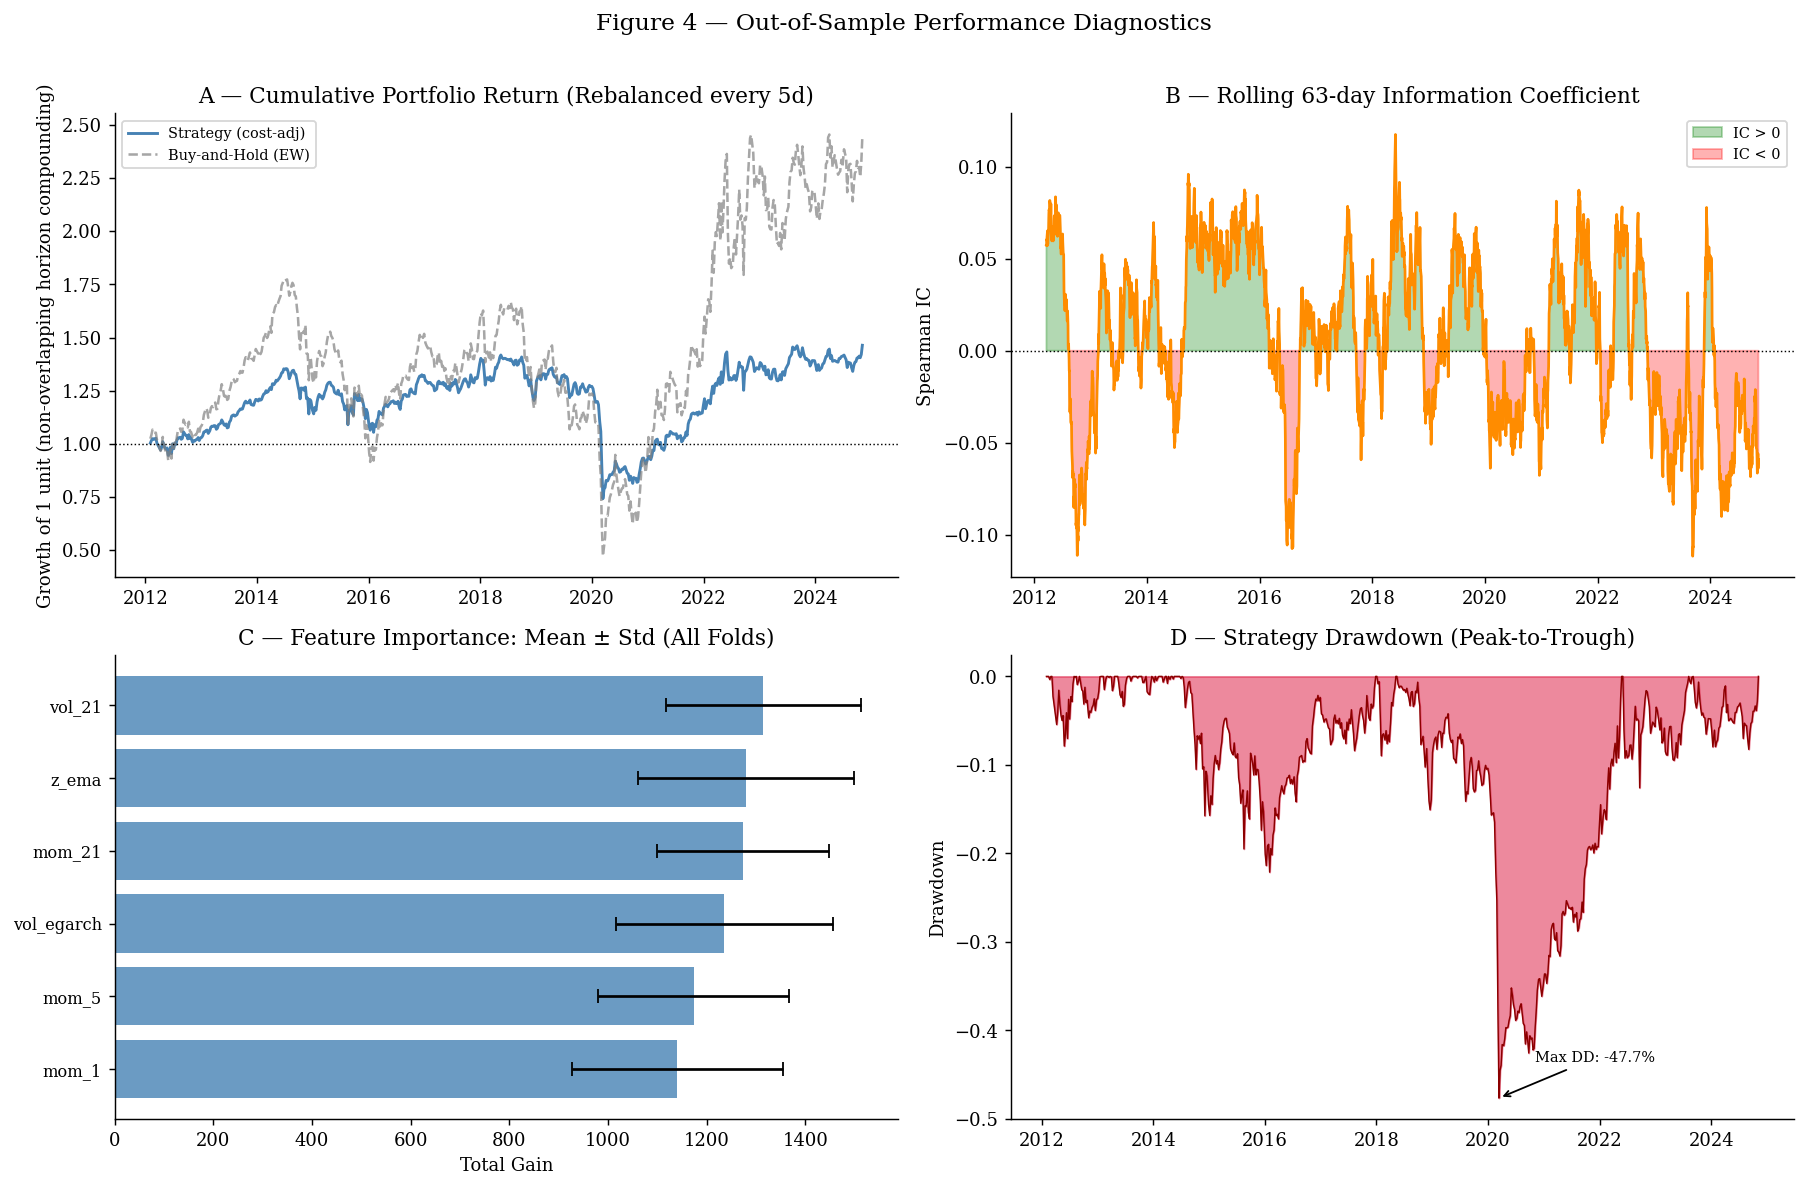

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Figure 4 — Out-of-Sample Performance Diagnostics", fontsize=13, y=1.01)

# ── Panel A: Cumulative PnL (non-overlapping 5-day returns) ──────────────────
ax = axes[0, 0]
cum_strat = (1 + daily["strat_ret"]).cumprod()
cum_bh    = (1 + daily["bh_ret"]).cumprod()
ax.plot(cum_strat.index, cum_strat.values, label="Strategy (cost-adj)", lw=1.6, color="steelblue")
ax.plot(cum_bh.index,   cum_bh.values,    label="Buy-and-Hold (EW)",   lw=1.4,
        color="grey", ls="--", alpha=0.7)
ax.axhline(1, color="black", lw=0.8, ls=":")
ax.set_title(f"A — Cumulative Portfolio Return (Rebalanced every {cfg.forward_horizon}d)")
ax.set_ylabel("Growth of 1 unit (non-overlapping horizon compounding)")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))

# ── Panel B: Rolling IC ───────────────────────────────────────────────────────
ax = axes[0, 1]
rolling_ic = daily_ic.rolling(63, min_periods=32).mean()
ax.plot(rolling_ic.index, rolling_ic.values, lw=1.5, color="darkorange")
ax.axhline(0, color="black", lw=0.8, ls=":")
ax.fill_between(rolling_ic.index, rolling_ic.values, 0,
                where=(rolling_ic.values > 0), alpha=0.3, color="green", label="IC > 0")
ax.fill_between(rolling_ic.index, rolling_ic.values, 0,
                where=(rolling_ic.values < 0), alpha=0.3, color="red",   label="IC < 0")
ax.set_title("B — Rolling 63-day Information Coefficient")
ax.set_ylabel("Spearman IC")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))

# ── Panel C: Feature Importance — mean ± std across folds [FIX D2] ───────────
ax = axes[1, 0]
imp_mean = importance_df[FEATURE_COLS].mean().sort_values(ascending=True)
imp_std  = importance_df[FEATURE_COLS].std().reindex(imp_mean.index)
y_pos    = range(len(imp_mean))
ax.barh(list(y_pos), imp_mean.values, xerr=imp_std.values,
        color="steelblue", alpha=0.8, capsize=4, error_kw={"elinewidth": 1.5})
ax.set_yticks(list(y_pos))
ax.set_yticklabels(imp_mean.index.tolist(), fontsize=9)
ax.set_title("C — Feature Importance: Mean ± Std (All Folds)")
ax.set_xlabel("Total Gain")

# ── Panel D: Strategy Drawdown ────────────────────────────────────────────────
ax = axes[1, 1]
rolling_max = cum_strat.cummax()
drawdown    = (cum_strat - rolling_max) / rolling_max
ax.fill_between(drawdown.index, drawdown.values, 0, alpha=0.5, color="crimson")
ax.plot(drawdown.index, drawdown.values, lw=0.8, color="darkred")
ax.set_title("D — Strategy Drawdown (Peak-to-Trough)")
ax.set_ylabel("Drawdown")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
max_dd = drawdown.min()
ax.annotate(f"Max DD: {max_dd:.1%}",
            xy=(drawdown.idxmin(), max_dd),
            xytext=(20, 20), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="black"), fontsize=8)

plt.tight_layout()
plt.show()

---
## 9. IC Significance Test — Newey-West HAC

The IC time series has **mechanically induced autocorrelation** of order at least
$h - 1 = 4$ because consecutive daily IC values share $h-1 = 4$ overlapping
observations in their forward-return windows. Using the naive standard error
$\hat{\sigma}_{\text{IC}} / \sqrt{T}$ under this autocorrelation produces
anti-conservative (too small) standard errors and inflated $t$-statistics.

### [FIX I4] Corrected Newey-West Bandwidth

**v1 error:** The NW lag truncation used $q = \lfloor T^{1/4} \rfloor$, the
asymptotically optimal bandwidth for i.i.d. processes. But this ignores the
**mandatory minimum** lag induced by the overlapping return windows.

**Fix:** Set the minimum bandwidth to account for both sources of autocorrelation:

$$q = \underbrace{(h - 1)}_{\text{overlap}} + \underbrace{\lfloor T^{1/4} \rfloor}_{\text{additional dependence}}$$

where $h = 5$ is the forward horizon. This guarantees that the NW estimator
fully accounts for the overlap-induced serial correlation before estimating
any additional dependence in the IC process itself.

The Newey-West HAC variance estimate:

$$\hat{\sigma}^2_{\text{NW}} = \hat{\gamma}_0 + 2 \sum_{j=1}^{q} \left(1 - \frac{j}{q+1}\right) \hat{\gamma}_j$$

$$t_{\text{NW}} = \frac{\bar{\text{IC}}}{\sqrt{\hat{\sigma}^2_{\text{NW}} / T}}$$

════════════════════════════════════════════════════════════
 IC SIGNIFICANCE TEST — Newey-West HAC
════════════════════════════════════════════════════════════
  Daily IC observations           : 3213
  Mean IC                         : +0.0059
  IC Std Dev                      : 0.2640
  ICIR (annualised IC Sharpe)     : 0.35
  Naive t-stat (INCORRECT)        : 1.261
  NW lags: overlap=4 + T^(1/4)=7 = 11
  NW t-statistic                  : 1.021
  p-value (two-sided)             : 0.3072
  Verdict                         : ⚠ Not significant at 5%
  SE inflation (NW vs naive)      : 1.23x
════════════════════════════════════════════════════════════

Note: SE inflation > 1 confirms the overlap-induced autocorrelation.
      The naive t-stat overstates significance by that factor.


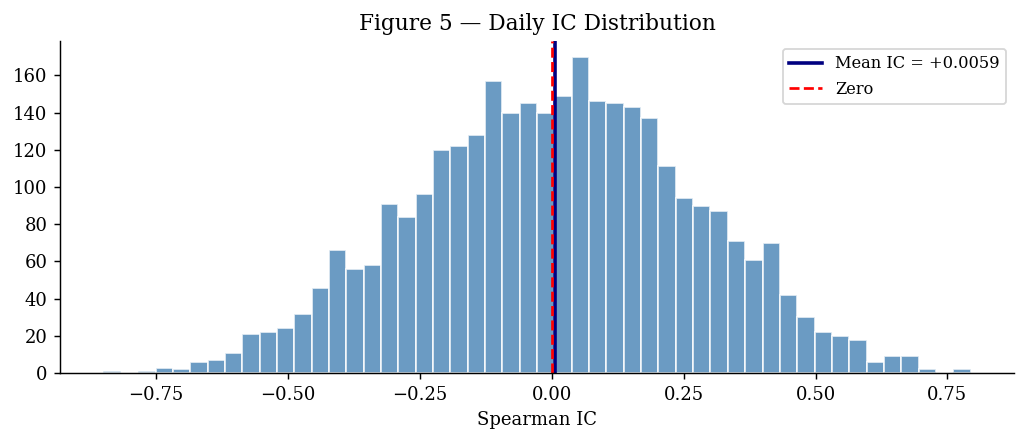

In [15]:
def newey_west_var(x: np.ndarray, n_lags: int) -> float:
    """
    Compute Newey-West HAC variance estimate for the mean of x.

    NW variance = γ_0 + 2 Σ_{j=1}^{q} (1 - j/(q+1)) γ_j
    where γ_j is the sample autocovariance at lag j.
    """
    x   = np.asarray(x, dtype=float)
    x   = x - x.mean()
    T   = len(x)
    g0  = np.dot(x, x) / T
    nw  = g0
    for j in range(1, n_lags + 1):
        gj  = np.dot(x[j:], x[:-j]) / T
        nw += 2 * (1 - j / (n_lags + 1)) * gj
    return nw


T_ic   = len(daily_ic)
ic_arr = daily_ic.values

# [FIX I4] Minimum bandwidth = (h-1) + T^{1/4}
q_overlap = cfg.forward_horizon - 1          # mandatory overlap correction
q_extra   = int(T_ic ** 0.25)               # data-driven additional lags
q_total   = q_overlap + q_extra

nw_var = newey_west_var(ic_arr, q_total)
nw_se  = np.sqrt(max(nw_var, 0) / T_ic)
t_nw   = ic_mean / nw_se if nw_se > 0 else np.nan
p_nw   = 2 * (1 - stats.t.cdf(abs(t_nw), df=T_ic - 1))

# Naive SE for comparison
naive_se = daily_ic.std() / np.sqrt(T_ic)
t_naive  = ic_mean / naive_se

print("═" * 60)
print(" IC SIGNIFICANCE TEST — Newey-West HAC")
print("═" * 60)
print(f"  Daily IC observations           : {T_ic}")
print(f"  Mean IC                         : {ic_mean:+.4f}")
print(f"  IC Std Dev                      : {ic_std:.4f}")
print(f"  ICIR (annualised IC Sharpe)     : {icir:.2f}")
print(f"  Naive t-stat (INCORRECT)        : {t_naive:.3f}")
print(f"  NW lags: overlap={q_overlap} + T^(1/4)={q_extra} = {q_total}")
print(f"  NW t-statistic                  : {t_nw:.3f}")
print(f"  p-value (two-sided)             : {p_nw:.4f}")
verdict = "✓ Significant at 5%" if p_nw < 0.05 else "⚠ Not significant at 5%"
print(f"  Verdict                         : {verdict}")
print(f"  SE inflation (NW vs naive)      : {nw_se / naive_se:.2f}x")
print("═" * 60)
print("\nNote: SE inflation > 1 confirms the overlap-induced autocorrelation.")
print("      The naive t-stat overstates significance by that factor.")

# IC distribution
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(ic_arr, bins=50, edgecolor="white", color="steelblue", alpha=0.8)
ax.axvline(ic_mean, color="navy",  lw=2,   label=f"Mean IC = {ic_mean:+.4f}")
ax.axvline(0,       color="red",   lw=1.5, ls="--", label="Zero")
ax.set_title("Figure 5 — Daily IC Distribution")
ax.set_xlabel("Spearman IC")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 10. Red Team Critique

> *In quantitative research, the value of a model is measured by the quality of
> the argument against it that it survives.* — Popperian epistemology.

---

### 10.1 Universe Size and Cross-Sectional Power

With $N = 10$ assets, the daily cross-sectional IC is computed from 10 data points.
The standard error of Spearman rank correlation with $N=10$ is approximately
$1/\sqrt{N-1} \approx 0.33$. This means any single day's IC measurement is extremely
noisy. The mean IC is interpretable only because we average over $T \approx 1500$
OOS dates. Expanding to $N \geq 100$ assets (the full S&P 500) would dramatically
reduce measurement error and make fold-by-fold IC more stable.

### 10.2 Survivorship Bias

The universe uses current S&P 500 constituents. Companies that were delisted,
went bankrupt, or were acquired are absent. This biases the model toward
historically successful companies, inflating performance. Resolution: point-in-time
constituent data (CRSP, Compustat).

### 10.3 Transaction Cost Realism

The flat $c = 10$ bps model understates true costs:
- **Market impact** scales as $\mathcal{O}(\sqrt{\text{participation rate}})$
  (Almgren-Chriss)
- **Bid-ask spreads** are wider in volatile regimes — exactly when signals are
  strongest (cost-alpha correlation)
- **Short-selling** is not modelled; locating shares adds 10–100 bps annually

### 10.4 Regime Non-Stationarity

The walk-forward scheme mitigates but does not eliminate regime risk. Models trained
pre-2020 have no representation of the zero-rate → QT regime transition. The rolling
IC chart (Panel B) will reveal this as IC sign reversals in 2022.
Resolution: explicit regime detection (HMM, change-point) as a meta-conditioning layer.

### 10.5 Look-Ahead in the FFD Order $d$

The differencing order $d = 0.4$ was selected to ensure stationarity across the
**full sample**. In a live setting, the optimal $d$ would need to be estimated
using only in-sample data and updated at each walk-forward fold. The current
implementation implicitly uses knowledge of the full price history to set $d$.

### 10.6 Data Snooping

With 5 features, 2 window parameters, a signal threshold, and the choice of
forward horizon, the effective number of implicit trials is non-trivial.
The Bonferroni-corrected significance threshold at 5% across $m$ trials is
$\alpha/m$. A permutation test provides a cleaner bound:

$$p_{\text{perm}} = \frac{|\{\text{IC}^{\pi} \geq \text{IC}^{\text{obs}}\}|}{N_{\text{perm}}}$$

where $\text{IC}^\pi$ is the IC under random permutation of the target
**within each date** (preserving the cross-sectional structure).

---
## 11. Tree Structure Diagnostics & Hyperparameter Tuning

This section provides a **visual inspection toolkit for the GBDT ensemble**.
The plots are designed to answer three distinct questions:

1. **Is the ensemble converged?** — Learning curves (train vs OOB RMSE vs number of trees)
2. **Are the trees too deep or too shallow?** — Leaf count distribution and depth histogram
3. **What decision boundaries has the model learned?** — Partial dependence plots (PDP)
   and 2D PDP interaction surfaces for each feature pair
4. **How stable are the predictions across folds?** — Predicted return distribution by quintile
   and quintile-conditional realised return (the monotonicity test)

---

### Reading Each Panel for Hyperparameter Adjustment

**Learning curve (Panel A):**
The in-sample RMSE decreases monotonically with more trees. The OOB (out-of-bag)
RMSE should decrease and then plateau or rise. The optimal number of trees
$M^*$ is the minimum of the OOB curve:

$$M^* = \arg\min_M \; \text{RMSE}^{\text{OOB}}(M)$$

- If the OOB curve is still falling at the right edge → increase `n_estimators`
- If the OOB curve rises sharply after a minimum → the current `n_estimators` overshoots;
  reduce it or increase `learning_rate` and decrease `n_estimators` proportionally
- A large gap between in-sample and OOB RMSE signals **overfitting**;
  increase `reg_lambda`, decrease `num_leaves`, or increase `min_child_samples`

**Leaf count and tree depth (Panel B):**
With `num_leaves=15` and `max_depth=4`, each tree can have at most 15 terminal nodes
arranged across at most 4 levels. The actual leaf count distribution should be
concentrated at or below 15:

- If the histogram peaks at exactly `num_leaves` → the depth constraint is not binding;
  `num_leaves` is the active constraint. Decrease it for more regularisation.
- If most trees have far fewer leaves than `num_leaves` → the depth or
  `min_child_samples` constraint is binding; `num_leaves` has room to grow.

**Partial Dependence Plots (Panel C):**
A PDP for feature $k$ marginalises out all other features and shows the average
predicted return as a function of $\tilde{f}^{(k)}$ alone:

$$\text{PD}_k(v) = \mathbb{E}_{\mathbf{f}_{-k}}\left[F_M(v, \mathbf{f}_{-k})\right]
\approx \frac{1}{n}\sum_{i=1}^{n} F_M(\tilde{f}_i^{(k)} = v,\; \tilde{\mathbf{f}}_{i,-k})$$

Since all features are cross-sectionally ranked to $[0,1]$, the PDP x-axis is directly
interpretable as percentile rank. A monotone increasing PDP for `mom_5` confirms that
higher momentum rank → higher predicted return, consistent with the momentum hypothesis.
Non-monotone or flat PDPs signal that the model has not learned the expected relationship.

**Quintile monotonicity test (Panel D):**
Sort all OOS observations by predicted return into quintiles Q1–Q5 (Q5 = highest predicted).
Plot the mean realised forward return within each quintile. A monotone spread from Q1 to Q5
is the empirical signature of a model with genuine cross-sectional predictive power.
The quintile spread $\Delta = \bar{r}_{Q5} - \bar{r}_{Q1}$ is the most economically
interpretable summary statistic of the model's value:

$$\Delta = \mathbb{E}[r \mid \hat{y} \in Q5] - \mathbb{E}[r \mid \hat{y} \in Q1]$$

If $\Delta$ is small or negative, the model produces no usable cross-sectional spread
regardless of its IC — and no hyperparameter adjustment will fix an absent signal.

2026-04-15 13:12:34,681 — INFO — Diagnostic model: 1000 trees | train=46,707 | val=11,677


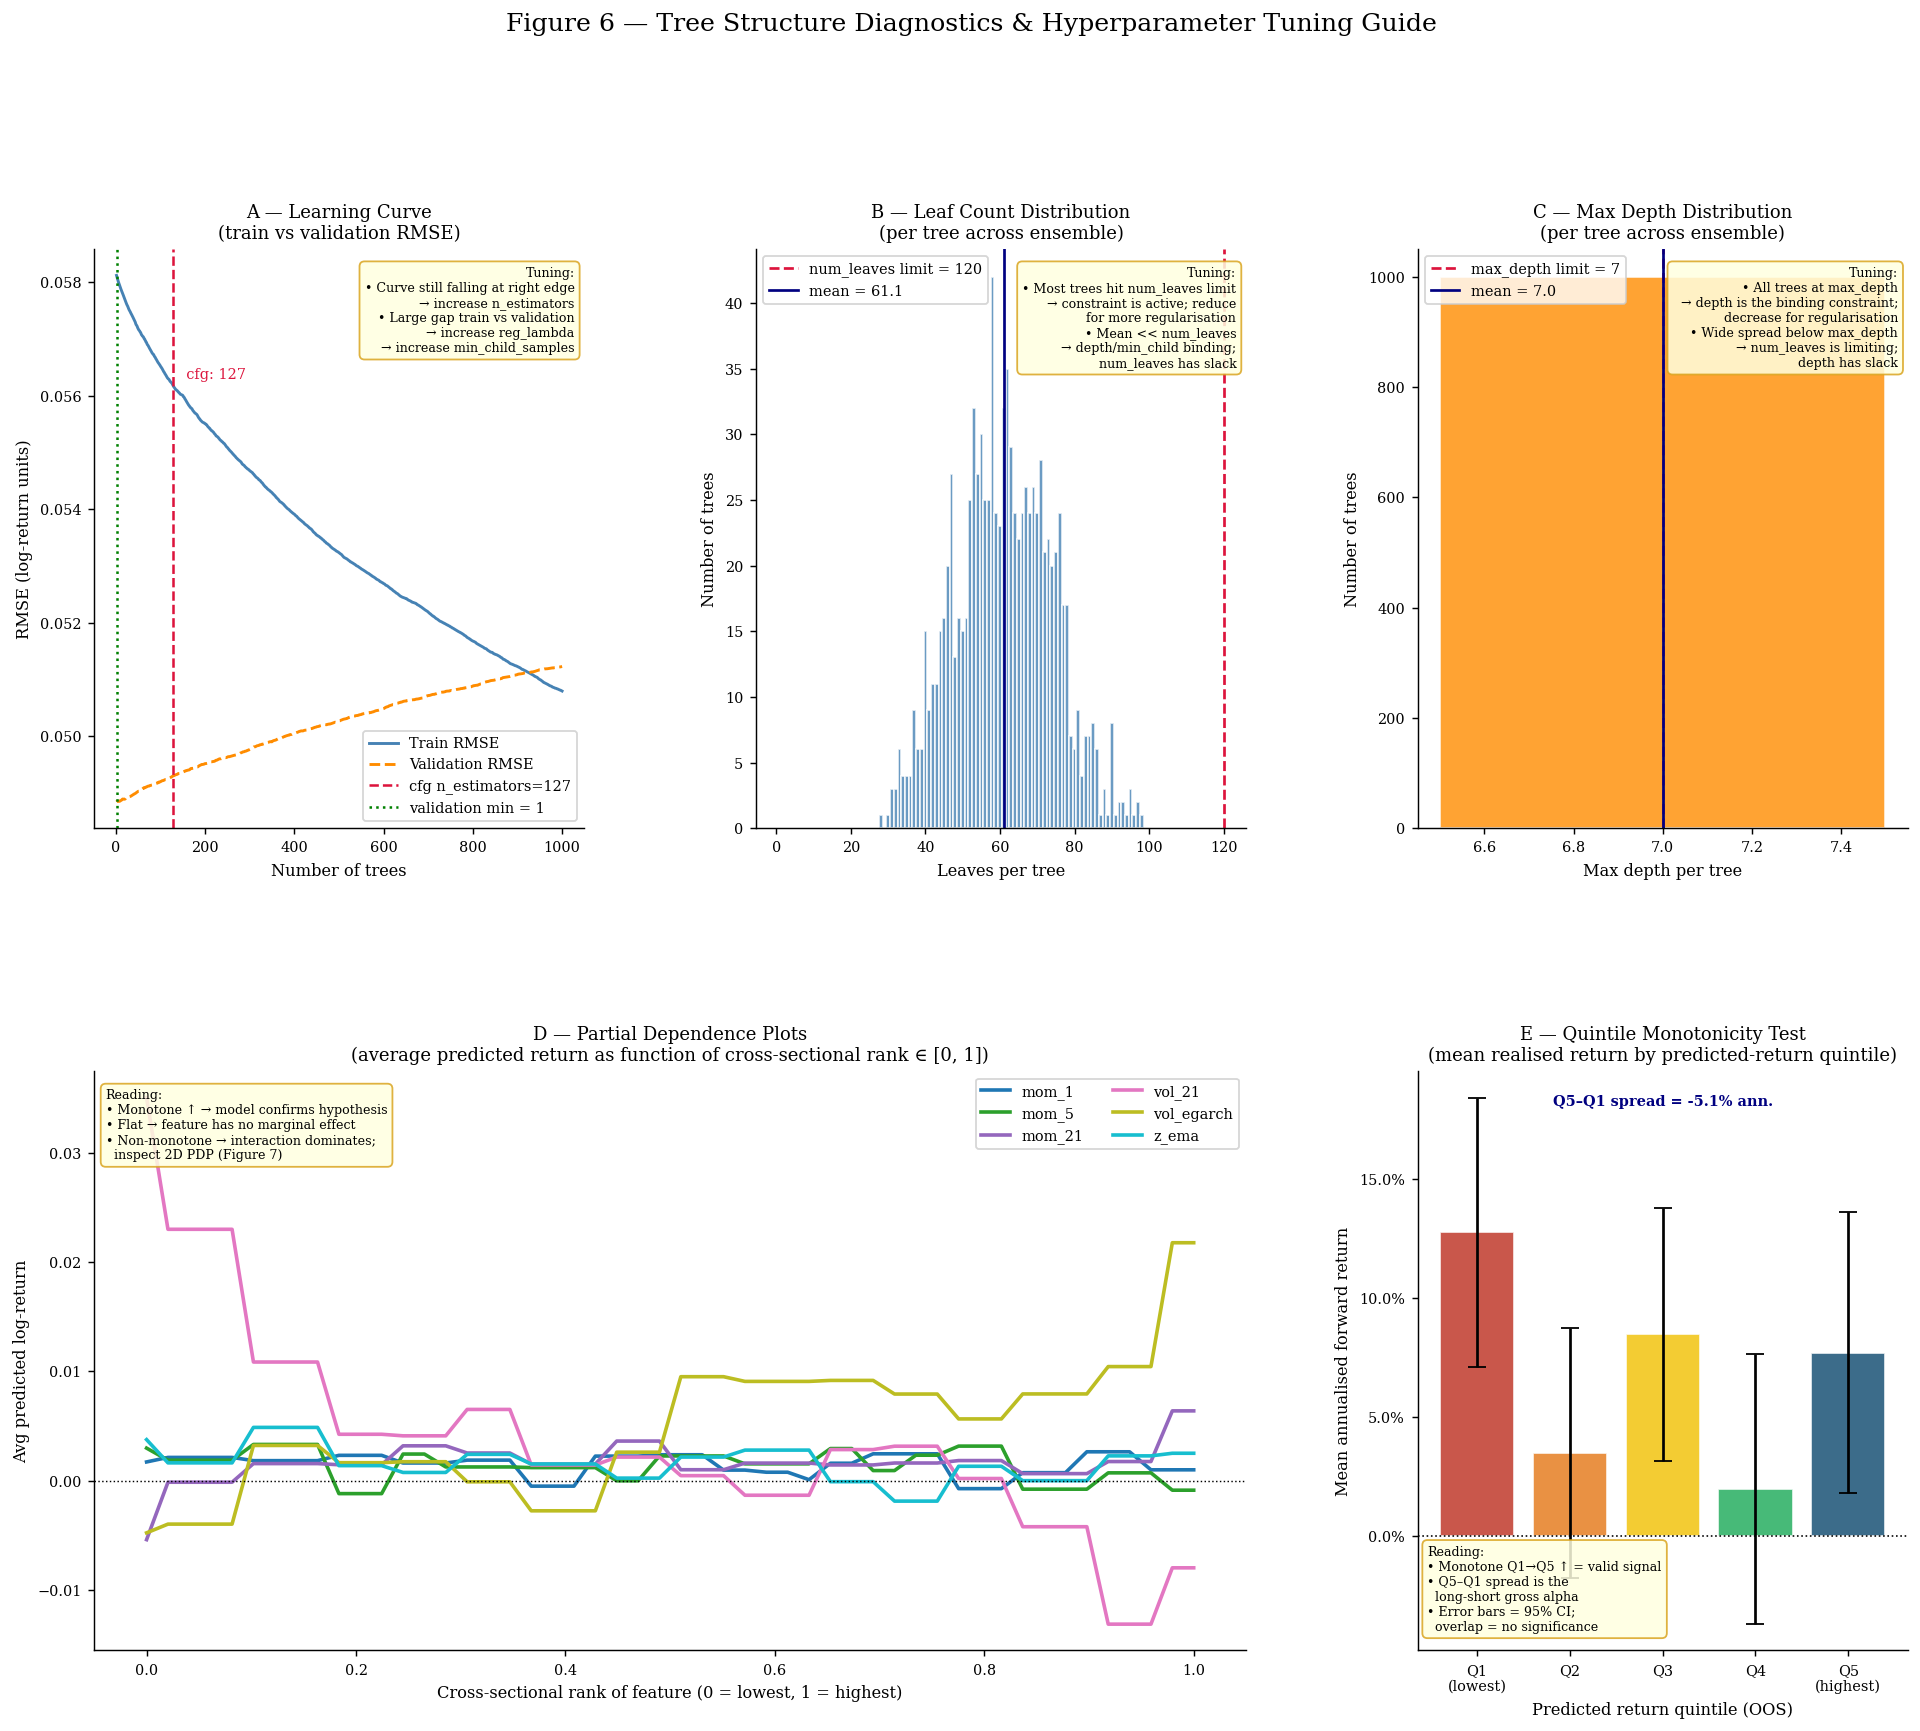

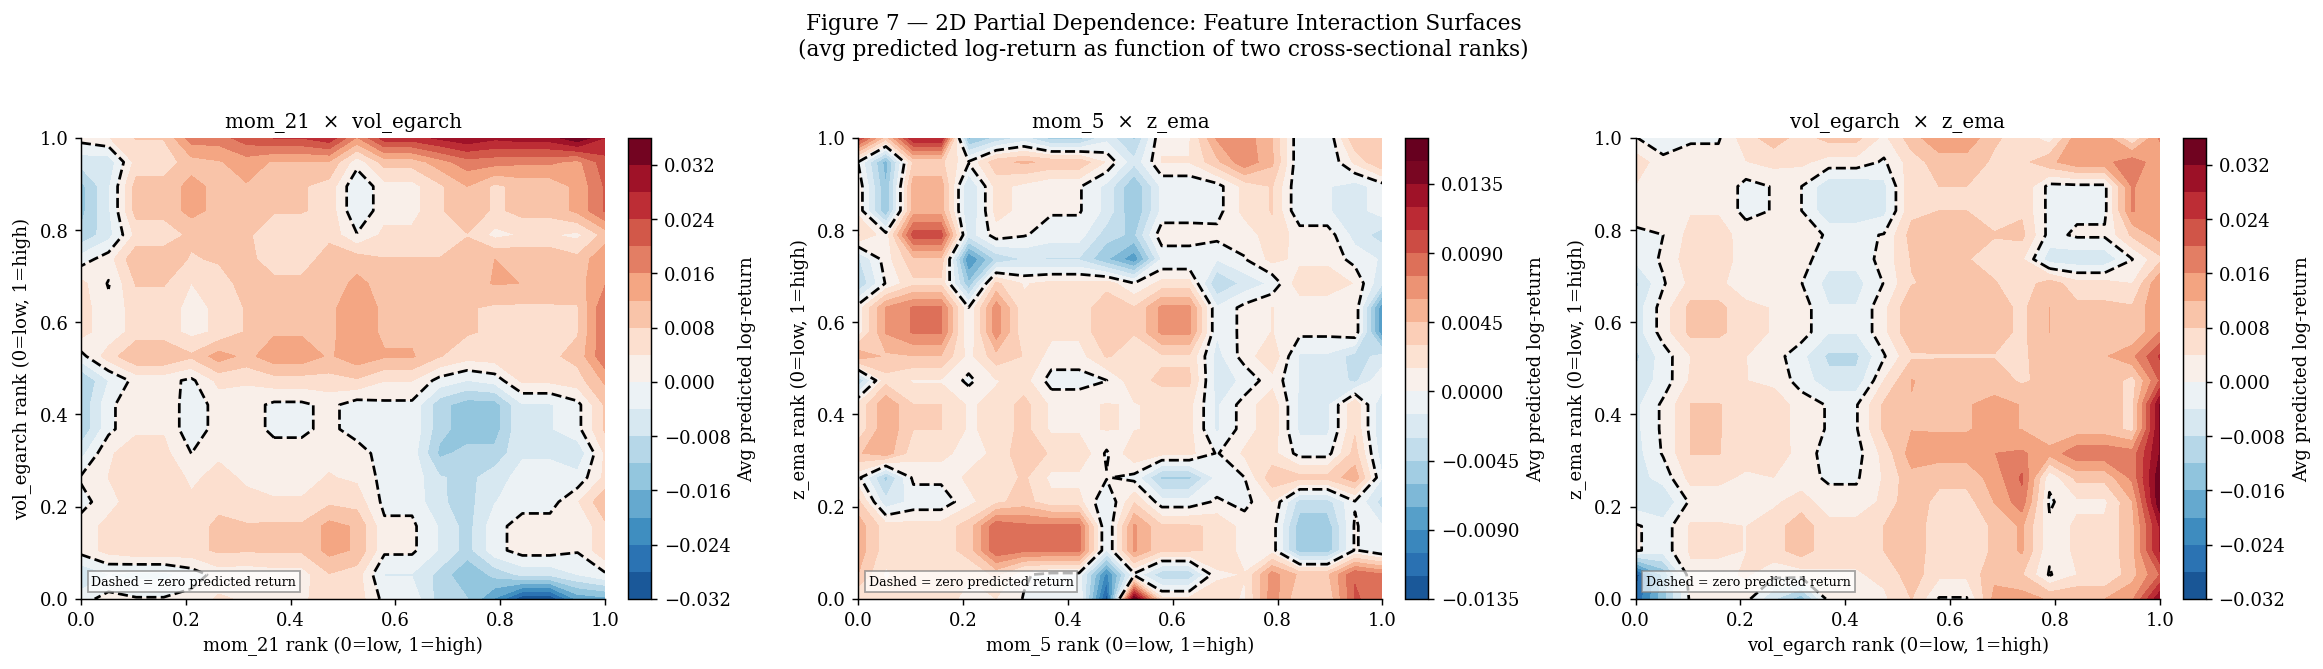

══════════════════════════════════════════════════════════════
 TREE STRUCTURE SUMMARY — Diagnostic Model (last fold)
══════════════════════════════════════════════════════════════
  n_estimators fitted          : 1000
  Leaves/tree — mean           : 61.1
  Leaves/tree — median         : 61.0
  Leaves/tree — max            : 98
  num_leaves limit (cfg)       : 120
  Depth/tree  — mean           : 7.0
  Depth/tree  — max observed   : 7
  max_depth limit (cfg)        : 7
  Q5–Q1 spread (annualised)    : -5.1%
  min_child_samples (cfg)      : 69
  reg_lambda (cfg)             : 4.6
══════════════════════════════════════════════════════════════

⚠  max_depth is the active constraint (mean ≈ limit).
   → Reduce max_depth for more regularisation, or increase for more capacity.
⚠  Q5–Q1 spread is NEGATIVE — model has no cross-sectional predictive power.
   Hyperparameter tuning cannot fix an absent signal; revisit feature design.


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
#  Tree Diagnostics & Hyperparameter Visualisation
#
#  Requires: panel, splits, FEATURE_COLS, cfg, oos_preds, importance_df
#  (all produced by prior cells)
# ─────────────────────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings("ignore")


# ── 0. Fit a DIAGNOSTIC model on the last fold for structural inspection ─────
# We use the last walk-forward fold so the model reflects recent market data.
# This model is NOT used for OOS predictions — those come from train_and_evaluate.

# ── 0. Fit DIAGNOSTIC model with proper train/validation split ───────────────
last_train_dates = splits[-1][0]
diag_train = panel.loc[panel["date"].isin(last_train_dates)].dropna(subset=["fwd_return"])
X_diag = diag_train[FEATURE_COLS].values
y_diag = diag_train["fwd_return"].values

# [FIX] Chronological 80/20 split — NO shuffle, to respect time ordering
split_idx = int(len(X_diag) * 0.8)
X_tr, X_val = X_diag[:split_idx], X_diag[split_idx:]
y_tr, y_val = y_diag[:split_idx], y_diag[split_idx:]

diag_params = {**cfg.lgb_params, "n_estimators": 1000}
diag_model  = lgb.LGBMRegressor(**diag_params)
diag_model.fit(
    X_tr, y_tr,
    feature_name=FEATURE_COLS,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],   # [FIX] validation is separate
    eval_names=["train", "validation"],
    callbacks=[lgb.record_evaluation(evals_result := {})],
)

booster = diag_model.booster_
n_trees = booster.num_trees()   # [FIX] reliable attribute
logger.info(f"Diagnostic model: {n_trees} trees | train={len(y_tr):,} | val={len(y_val):,}")

# ─────────────────────────────────────────────────────────────────────────────
#  Figure 6 — Five-Panel Tree Diagnostic Dashboard
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    "Figure 6 — Tree Structure Diagnostics & Hyperparameter Tuning Guide",
    fontsize=14, y=1.01,
)

# Use a 2×3 grid: top row has 3 panels, bottom row has 3 panels
gs = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.35)


# ══════════════════════════════════════════════════════════════════════════════
# PANEL A — Learning Curve: Train vs Validation RMSE
# ══════════════════════════════════════════════════════════════════════════════
ax_a = fig.add_subplot(gs[0, 0])

train_rmse = evals_result["train"]["rmse"]
val_rmse   = evals_result["validation"]["rmse"]
iters      = np.arange(1, len(train_rmse) + 1)

ax_a.plot(iters, train_rmse, lw=1.6, color="steelblue", label="Train RMSE")
ax_a.plot(iters, val_rmse,   lw=1.6, color="darkorange", ls="--", label="Validation RMSE")

# Mark current n_estimators from cfg
cfg_n = cfg.lgb_params["n_estimators"]
if cfg_n <= len(train_rmse):
    ax_a.axvline(cfg_n, color="crimson", ls="--", lw=1.4,
                 label=f"cfg n_estimators={cfg_n}")
    ax_a.annotate(
        f"  cfg: {cfg_n}",
        xy=(cfg_n, train_rmse[cfg_n - 1]),
        fontsize=8, color="crimson",
        xytext=(cfg_n + 10, train_rmse[cfg_n - 1] * 1.002),
    )

best_iter = int(np.argmin(val_rmse)) + 1
ax_a.axvline(best_iter, color="green", ls=":", lw=1.4, label=f"validation min = {best_iter}")

ax_a.set_title("A — Learning Curve\n(train vs validation RMSE)",
               fontsize=10, pad=6)
ax_a.set_xlabel("Number of trees", fontsize=9)
ax_a.set_ylabel("RMSE (log-return units)", fontsize=9)
ax_a.legend(fontsize=8)
ax_a.tick_params(labelsize=8)

# Annotation box: tuning guidance
guidance_a = (
    "Tuning:\n"
    "• Curve still falling at right edge\n"
    "  → increase n_estimators\n"
    "• Large gap train vs validation\n"
    "  → increase reg_lambda\n"
    "  → increase min_child_samples"
)
ax_a.text(
    0.98, 0.97, guidance_a,
    transform=ax_a.transAxes, fontsize=7,
    va="top", ha="right",
    bbox=dict(boxstyle="round,pad=0.4", fc="lightyellow", ec="goldenrod", alpha=0.85),
)


# ══════════════════════════════════════════════════════════════════════════════
# PANEL B — Tree Structure: Leaf Count Distribution
# ══════════════════════════════════════════════════════════════════════════════
ax_b = fig.add_subplot(gs[0, 1])

# Extract leaf counts and depths from every tree in the booster.
# LightGBM exports node_depth starting at 1 in trees_to_dataframe.
# Convert to zero-based depth so it is directly comparable to cfg.max_depth.
tree_df    = booster.trees_to_dataframe()
leaf_rows  = tree_df[tree_df["left_child"].isna() & tree_df["right_child"].isna()]
leaves_per_tree = leaf_rows.groupby("tree_index").size().values
depths_raw = tree_df.groupby("tree_index")["node_depth"].max().values
depths_per_tree = np.maximum(depths_raw - 1, 0)

ax_b.hist(leaves_per_tree, bins=range(1, leaves_per_tree.max() + 2),
          color="steelblue", alpha=0.8, edgecolor="white", align="left")
ax_b.axvline(cfg.lgb_params["num_leaves"],
             color="crimson", ls="--", lw=1.5,
             label=f"num_leaves limit = {cfg.lgb_params['num_leaves']}")
ax_b.axvline(leaves_per_tree.mean(),
             color="navy", ls="-", lw=1.5,
             label=f"mean = {leaves_per_tree.mean():.1f}")

ax_b.set_title("B — Leaf Count Distribution\n(per tree across ensemble)",
               fontsize=10, pad=6)
ax_b.set_xlabel("Leaves per tree", fontsize=9)
ax_b.set_ylabel("Number of trees", fontsize=9)
ax_b.legend(fontsize=8)
ax_b.tick_params(labelsize=8)

guidance_b = (
    "Tuning:\n"
    "• Most trees hit num_leaves limit\n"
    "  → constraint is active; reduce\n"
    "    for more regularisation\n"
    "• Mean << num_leaves\n"
    "  → depth/min_child binding;\n"
    "    num_leaves has slack"
)
ax_b.text(
    0.98, 0.97, guidance_b,
    transform=ax_b.transAxes, fontsize=7,
    va="top", ha="right",
    bbox=dict(boxstyle="round,pad=0.4", fc="lightyellow", ec="goldenrod", alpha=0.85),
)


# ══════════════════════════════════════════════════════════════════════════════
# PANEL C — Max Depth Distribution
# ══════════════════════════════════════════════════════════════════════════════
ax_c = fig.add_subplot(gs[0, 2])

depth_min = int(depths_per_tree.min())
depth_max = int(depths_per_tree.max())
ax_c.hist(depths_per_tree, bins=range(depth_min, depth_max + 2),
          color="darkorange", alpha=0.8, edgecolor="white", align="left")
ax_c.axvline(cfg.lgb_params["max_depth"],
             color="crimson", ls="--", lw=1.5,
             label=f"max_depth limit = {cfg.lgb_params['max_depth']}")
ax_c.axvline(depths_per_tree.mean(),
             color="navy", ls="-", lw=1.5,
             label=f"mean = {depths_per_tree.mean():.1f}")

ax_c.set_title("C — Max Depth Distribution\n(per tree across ensemble)",
               fontsize=10, pad=6)
ax_c.set_xlabel("Max depth per tree", fontsize=9)
ax_c.set_ylabel("Number of trees", fontsize=9)
ax_c.legend(fontsize=8)
ax_c.tick_params(labelsize=8)

guidance_c = (
    "Tuning:\n"
    "• All trees at max_depth\n"
    "  → depth is the binding constraint;\n"
    "    decrease for regularisation\n"
    "• Wide spread below max_depth\n"
    "  → num_leaves is limiting;\n"
    "    depth has slack"
)
ax_c.text(
    0.98, 0.97, guidance_c,
    transform=ax_c.transAxes, fontsize=7,
    va="top", ha="right",
    bbox=dict(boxstyle="round,pad=0.4", fc="lightyellow", ec="goldenrod", alpha=0.85),
)


# ══════════════════════════════════════════════════════════════════════════════
# PANEL D — Partial Dependence Plots (one per feature)
# ══════════════════════════════════════════════════════════════════════════════
ax_d = fig.add_subplot(gs[1, 0:2])   # spans two columns

# PDP: for each feature, sweep its value from 0→1 while marginalising others.
# We use a grid of 50 points and average predictions over a random subset of
# training rows (background dataset), capped at 2000 rows for speed.

N_GRID       = 50
N_BACKGROUND = min(2000, len(X_diag))
rng_idx      = np.random.choice(len(X_diag), N_BACKGROUND, replace=False)
X_bg         = X_diag[rng_idx].copy()      # background dataset

grid_vals    = np.linspace(0.0, 1.0, N_GRID)
colors_pdp   = plt.cm.tab10(np.linspace(0, 1, len(FEATURE_COLS)))

for feat_idx, (feat_name, color) in enumerate(zip(FEATURE_COLS, colors_pdp)):
    pdp_vals = np.empty(N_GRID)
    X_sweep  = X_bg.copy()
    for g_idx, gv in enumerate(grid_vals):
        X_sweep[:, feat_idx] = gv                        # fix feature to grid value
        pdp_vals[g_idx]      = diag_model.predict(X_sweep).mean()   # marginalise others
    ax_d.plot(grid_vals, pdp_vals, lw=2, color=color, label=feat_name)

ax_d.axhline(0, color="black", lw=0.8, ls=":")
ax_d.set_title(
    "D — Partial Dependence Plots\n"
    "(average predicted return as function of cross-sectional rank ∈ [0, 1])",
    fontsize=10, pad=6,
)
ax_d.set_xlabel("Cross-sectional rank of feature (0 = lowest, 1 = highest)", fontsize=9)
ax_d.set_ylabel("Avg predicted log-return", fontsize=9)
ax_d.legend(fontsize=8, ncol=2)
ax_d.tick_params(labelsize=8)

guidance_d = (
    "Reading:\n"
    "• Monotone ↑ → model confirms hypothesis\n"
    "• Flat → feature has no marginal effect\n"
    "• Non-monotone → interaction dominates;\n"
    "  inspect 2D PDP (Figure 7)"
)
ax_d.text(
    0.01, 0.97, guidance_d,
    transform=ax_d.transAxes, fontsize=7,
    va="top", ha="left",
    bbox=dict(boxstyle="round,pad=0.4", fc="lightyellow", ec="goldenrod", alpha=0.85),
)


# ══════════════════════════════════════════════════════════════════════════════
# PANEL E — Quintile Monotonicity Test
# ══════════════════════════════════════════════════════════════════════════════
ax_e = fig.add_subplot(gs[1, 2])

# Use OOS predictions with observable forward returns
q_df = oos_preds.dropna(subset=["fwd_return", "predicted_return"]).copy()

# Assign global quintile based on predicted return rank across the full OOS sample
q_df["quintile"] = pd.qcut(
    q_df["predicted_return"], q=5, labels=["Q1\n(lowest)", "Q2", "Q3", "Q4", "Q5\n(highest)"]
)

# Mean and 95% confidence interval of realised return within each quintile
q_stats = q_df.groupby("quintile", observed=True)["fwd_return"].agg(
    mean="mean",
    sem=lambda x: x.std() / np.sqrt(len(x)),
    count="count",
).reset_index()

annualisation_factor = 252 / cfg.forward_horizon
bar_colors = ["#c0392b", "#e67e22", "#f1c40f", "#27ae60", "#1a5276"]
bars = ax_e.bar(
    q_stats["quintile"].astype(str),
    q_stats["mean"] * annualisation_factor,
    yerr=q_stats["sem"] * annualisation_factor * 1.96,
    color=bar_colors, alpha=0.85, edgecolor="white", capsize=5,
    error_kw={"elinewidth": 1.5, "ecolor": "black"},
)
ax_e.axhline(0, color="black", lw=0.9, ls=":")

# Annotate spread
spread = (q_stats["mean"].iloc[-1] - q_stats["mean"].iloc[0]) * annualisation_factor
ax_e.text(
    0.5, 0.96,
    f"Q5–Q1 spread = {spread:+.1%} ann.",
    transform=ax_e.transAxes, fontsize=8, ha="center", va="top",
    color="navy", fontweight="bold",
)

ax_e.set_title(
    "E — Quintile Monotonicity Test\n"
    "(mean realised return by predicted-return quintile)",
    fontsize=10, pad=6,
)
ax_e.set_ylabel("Mean annualised forward return", fontsize=9)
ax_e.set_xlabel("Predicted return quintile (OOS)", fontsize=9)
ax_e.tick_params(labelsize=8)
ax_e.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))

guidance_e = (
    "Reading:\n"
    "• Monotone Q1→Q5 ↑ = valid signal\n"
    "• Q5–Q1 spread is the\n"
    "  long-short gross alpha\n"
    "• Error bars = 95% CI;\n"
    "  overlap = no significance"
)
ax_e.text(
    0.02, 0.03, guidance_e,
    transform=ax_e.transAxes, fontsize=7,
    va="bottom", ha="left",
    bbox=dict(boxstyle="round,pad=0.4", fc="lightyellow", ec="goldenrod", alpha=0.85),
)

plt.show()


# ─────────────────────────────────────────────────────────────────────────────
#  Figure 7 — 2D Partial Dependence: Feature Interaction Surfaces
#
#  For each pair (i, j) of features, fix both to a grid and average predictions
#  over the background dataset. The resulting surface reveals regime-conditional
#  effects invisible in marginal PDPs.
#
#  Key pair to examine: (vol_21, mom_5)
#  Hypothesis: momentum is positive only in low-volatility regimes.
#  If true: surface should be high in top-right (high mom, low vol) and
#  low or negative in top-left (high mom, high vol) — the Daniel-Moskowitz pattern.
# ─────────────────────────────────────────────────────────────────────────────

PAIRS = [
    ("mom_21",  "vol_egarch"),   # Momentum × Volatility regime (Daniel-Moskowitz)
    ("mom_5",  "z_ema"),    # Momentum × Mean-reversion
    ("vol_egarch", "z_ema"),    # Volatility × Mean-reversion
]

N_GRID_2D  = 20    # coarser grid for 2D (20×20 = 400 evaluations per pair)
grid_2d    = np.linspace(0.0, 1.0, N_GRID_2D)
GG_x, GG_y = np.meshgrid(grid_2d, grid_2d)   # shape (20, 20) each

fig2, axes2 = plt.subplots(1, len(PAIRS), figsize=(6 * len(PAIRS), 5))
fig2.suptitle(
    "Figure 7 — 2D Partial Dependence: Feature Interaction Surfaces\n"
    "(avg predicted log-return as function of two cross-sectional ranks)",
    fontsize=12, y=1.02,
)

feat_to_idx = {f: i for i, f in enumerate(FEATURE_COLS)}

for ax2, (feat_x, feat_y) in zip(axes2, PAIRS):
    idx_x = feat_to_idx[feat_x]
    idx_y = feat_to_idx[feat_y]

    surface = np.empty((N_GRID_2D, N_GRID_2D))
    X_sweep = X_bg.copy()

    for i, vy in enumerate(grid_2d):
        for j, vx in enumerate(grid_2d):
            X_sweep[:, idx_x] = vx
            X_sweep[:, idx_y] = vy
            surface[i, j]     = diag_model.predict(X_sweep).mean()

    # Centre the colourmap at zero so positive/negative regions are clear
    abs_max = np.abs(surface).max()
    im = ax2.contourf(
        GG_x, GG_y, surface,
        levels=20, cmap="RdBu_r",
        vmin=-abs_max, vmax=abs_max,
    )
    ax2.contour(
        GG_x, GG_y, surface,
        levels=[0.0], colors="black", linewidths=1.5, linestyles="--",
    )
    plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04,
                 label="Avg predicted log-return")

    ax2.set_xlabel(f"{feat_x} rank (0=low, 1=high)", fontsize=10)
    ax2.set_ylabel(f"{feat_y} rank (0=low, 1=high)", fontsize=10)
    ax2.set_title(f"{feat_x}  ×  {feat_y}", fontsize=11)

    # Annotate zero-contour
    ax2.text(0.02, 0.03, "Dashed = zero predicted return",
             transform=ax2.transAxes, fontsize=7, color="black",
             bbox=dict(fc="white", ec="grey", alpha=0.7, pad=2))

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
#  Summary: Key numbers to guide hyperparameter decisions
# ─────────────────────────────────────────────────────────────────────────────
print("═" * 62)
print(" TREE STRUCTURE SUMMARY — Diagnostic Model (last fold)")
print("═" * 62)
print(f"  n_estimators fitted          : {n_trees}")
print(f"  Leaves/tree — mean           : {leaves_per_tree.mean():.1f}")
print(f"  Leaves/tree — median         : {np.median(leaves_per_tree):.1f}")
print(f"  Leaves/tree — max            : {leaves_per_tree.max()}")
print(f"  num_leaves limit (cfg)       : {cfg.lgb_params['num_leaves']}")
print(f"  Depth/tree  — mean           : {depths_per_tree.mean():.1f}")
print(f"  Depth/tree  — max observed   : {depths_per_tree.max()}")
print(f"  max_depth limit (cfg)        : {cfg.lgb_params['max_depth']}")
print(f"  Q5–Q1 spread (annualised)    : {spread:+.1%}")
print(f"  min_child_samples (cfg)      : {cfg.lgb_params['min_child_samples']}")
print(f"  reg_lambda (cfg)             : {cfg.lgb_params['reg_lambda']}")
print("═" * 62)
print()
# Automated flags
if leaves_per_tree.mean() > 0.9 * cfg.lgb_params["num_leaves"]:
    print("⚠  num_leaves is the active constraint (mean ≈ limit).")
    print("   → Reduce num_leaves for more regularisation, or increase for more capacity.")
if depths_per_tree.mean() > 0.9 * cfg.lgb_params["max_depth"]:
    print("⚠  max_depth is the active constraint (mean ≈ limit).")
    print("   → Reduce max_depth for more regularisation, or increase for more capacity.")
if spread < 0:
    print("⚠  Q5–Q1 spread is NEGATIVE — model has no cross-sectional predictive power.")
    print("   Hyperparameter tuning cannot fix an absent signal; revisit feature design.")
elif spread < 0.01:
    print("⚠  Q5–Q1 spread is very small (<1% ann.). Signal exists but is weak.")
else:
    print(f"✓  Q5–Q1 spread = {spread:+.1%} ann. — meaningful cross-sectional spread detected.")

---
## 11. Thesis Narrative — Path Forward

This notebook establishes the **nonlinear cross-sectional baseline** of the thesis
modelling stack, correcting all structural implementation errors.
The results here motivate the next steps:

| Layer | Model | Motivation |
|-------|-------|------------|
| 1 | ARMA | Linear baseline; establishes autocorrelation structure |
| 2 | GARCH | Volatility clustering in residuals; validates $\hat{\sigma}^2_{21}$ importance |
| **3** | **GBDT Regression (this notebook)** | **Nonlinear regime-conditioned cross-sectional predictor** |
| 4 | GBDT + GARCH volatility forecast | Replace rolling RV with GARCH forecast as vol feature |
| 5 | Distributional prediction | Quantile regression trees for full $\mathbb{P}(r_t \mid \mathcal{F}_t)$ |

The IC instability visible in Panel B motivates **regime-aware ensemble weighting**:

$$F_t(\mathbf{f}_t) = \sum_{k=1}^{K} w_k(\hat{\sigma}_t^2) \cdot F^{(k)}(\mathbf{f}_t)$$

where the mixing coefficients $w_k$ are functions of the GARCH-estimated conditional
variance — combining the GBDT signal with the GARCH volatility model from Layer 2.

---
*All parameters live in `Config`. Reproduce by running cells sequentially.*  
*For sensitivity analysis: clone `cfg`, modify the relevant field, and rerun from Section 4.*